## Abstract:


We generate realistic rough fracture walls by synthesizing **self-affine (fractal) surfaces** with an FFT method: roughness grows with scale as
$$
\sigma_{\delta h}(\Delta \ell)\propto \Delta \ell^{H},
$$
and we enforce a power-law spectrum by prescribing Fourier amplitudes
$$
A(K)\propto K^{-\beta/2},\qquad \beta=2H+1,
$$
with random phases and an inverse transform
$$
z(x,y)=\Re{\mathrm{IFFT}[\hat z]}.
$$
The surface is then rescaled to match the target roughness magnitude (linked to JRC):
$$
z \leftarrow z,\frac{\sigma_{\delta h,\text{target}}}{\sigma_{\delta h,\text{num}}},
$$
and two perfectly mated walls are formed around an initial aperture (b_0):
$$
z_{\text{lower}}=-\tfrac12 z-\tfrac12 b_0,\qquad z_{\text{upper}}=+\tfrac12 z+\tfrac12 b_0.
$$

Next, we simulate **shear damage and closure under stress**. Local slopes facing the shear direction are evaluated and asperities are progressively degraded when sliding demand exceeds resistance, using a Mohr–Coulomb form
$$
\tau=c_{\text{joint}}+\sigma_n\tan\varphi,
$$
with (\varphi) and JCS varying with (\sigma_n). After shearing (implemented as slope-clipping plus a periodic shift of one wall), we compute the spatially varying aperture using the mid-plane geometry
$$
a=\max!\left(\frac{\Delta z_c}{n_{m,z}},0\right).
$$
Finally, normal compression is applied with a Barton–Bandis hyperbola
$$
\Delta b_n(\sigma_n)=\frac{\sigma_n}{\sigma_n+k_n\Delta b_m},\Delta b_m,
$$
giving the closed aperture field
$$
a_{\text{closed}}=\max(a-\Delta b_n,0).
$$




## 1. Self-affine synthetic fracture surfaces (Stigsson-type, FFT)

Fracture surfaces are represented as **self-affine mono-fractal** surfaces, following the approach of Stigsson and Mas Ivars (2018) and Stigsson *et al.* (2025).
The fracture geometry is described by a height (or aperture) function $a(x,y)$ defined over a planar domain; $a(x,y)$ is the elevation of the surface above a reference plane. In the implementation, $a(x,y)$ and $z(x,y)$ are used interchangeably as the surface height.

A self-affine surface is characterized by:

1. The **Hurst exponent** $H$, which controls how roughness grows with scale. For a self-affine surface embedded in 3D,
   $$
   H = 3 - D_\mathrm{surface},
   $$
   where $D_\mathrm{surface}$ is the fractal dimension of the surface. A smooth plane has $D_\mathrm{surface} = 2$ and $H = 1$; rougher surfaces have $D_\mathrm{surface} \to 3$ and thus smaller $H$.

2. A **magnitude parameter** for the height differences, usually taken as the standard deviation of height differences $\sigma_{\delta h}(\Delta \ell)$ at a given lag $\Delta \ell$.

For a one-dimensional trace $h(x)$ of the surface, the height difference over a step $\Delta \ell$ is
$$
\delta h(x;\Delta \ell) = h(x + \Delta \ell) - h(x),
$$

and the corresponding standard deviation is

$$
\sigma_{\delta h}(\Delta \ell)
=\sqrt{\big\langle \big[h(x+\Delta \ell) - h(x)\big]^2 \big\rangle},
$$
where $\langle\cdot\rangle$ denotes averaging along the profile. Following Stigsson *et al.*, the reference lag is
$$
\Delta \ell = 1,\mathrm{mm}
\quad\Rightarrow\quad
\sigma_{\delta h}(1,\mathrm{mm}).
$$

### 1.1 JRC--$H$--$\sigma_{\delta h}$ link

Stigsson and Mas Ivars link the fractal parameters $(H, \sigma_{\delta h})$ to the classical Joint Roughness Coefficient (JRC) by fitting a multiple linear regression model to Barton’s ten standard roughness profiles. This regression provides a continuous mapping between an engineering $\mathrm{JRC}$ value and the pair $(H,\sigma_{\delta h}(1\,\mathrm{mm}))$, where $\sigma_{\delta h}(1\,\mathrm{mm})$ is expressed in meters.

In the present implementation, this regression is \emph{not} re-derived and evaluated. Instead, the published anchor values reported by Stigsson for the parameter study are used directly:


 1. $\mathrm{JRC}=4,7,10$,
 2. corresponding $H=0.7,0.8,0.9$,
 3. corresponding $\sigma_{\delta h}(1\,\mathrm{mm}) = 0.0969,\,0.1440,\,0.1910\ \mathrm{mm}$.


**Reason:** using the published anchor values is simpler and guarantees exact consistency with Stigsson \emph{et al.} for these studied $\mathrm{JRC}$ values, without re-implementing the regression.

Self-affine scaling implies
$$
\sigma_{\delta h}(\Delta \ell) \propto \Delta \ell^{H},
$$
so for a grid spacing $dx$ (in meters):
$$
\sigma_{\delta h}(1\,\mathrm{mm})
= \sigma_{\delta h}(dx)\left(\frac{1\,\mathrm{mm}}{dx}\right)^{H},
\qquad
\sigma_{\delta h}(dx)
= \sigma_{\delta h}(1\,\mathrm{mm})\left(\frac{dx}{1\,\mathrm{mm}}\right)^{H}.
$$
These relations allow conversion between roughness measured at a given sampling step $dx$ and the value required in the JRC-based parameterisation.



In the present implementation, this **continuous** JRC–$H$–$\sigma_{\delta h}$ relation is *not* recomputed. Instead, a **fixed table** is used for three JRC values taken directly from Stigsson’s parameter study:

* $\mathrm{JRC} = 4, 7, 10$,
* corresponding $H = 0.7, 0.8, 0.9$,
* corresponding $\sigma_{\delta h}(1,\mathrm{mm}) = 0.0969, 0.1440, 0.1910\ \mathrm{mm}$.

**Reason:** using the published table is simpler and guarantees exact consistency with Stigsson *et al.* for the studied JRC values, without re-implementing the regression.

In this work, $\mathrm{JRC}\in[4,10]$ and $\sigma_n\in[0.2,20]\,\mathrm{MPa}$ are enforced to avoid extrapolation beyond the published anchor parameterisation; values outside these ranges are rejected.


### 1.2 Power spectrum and FFT-based generation

To generate synthetic self-affine surfaces with prescribed $H$ and $\sigma_{\delta h}$, Stigsson *et al.* use a **spectral (FFT-based)** method.
For reference, the 1D PSD of a self-affine profile follows $S_{1D}(f) \propto f^{-(2H+1)}$, but for **2D surfaces** the PSD scales as $S_{2D}(K) \propto K^{-(2H+2)}$, giving amplitude $A(K) \propto K^{-(H+1)}$.

In the present work, the same idea is implemented directly in **2D**:

1. A periodic grid of size $2049 \times 2049$ points is defined, with
   $$
   \Delta x = \Delta y = 1,\mathrm{mm},
   $$
   giving a domain of about $2.049 \times 2.049,\mathrm{m}^2$.

2. FFT frequencies $(k_x, k_y)$ are computed in both directions and the radial wavenumber
   $$
   K = \sqrt{k_x^2 + k_y^2}
   $$
   is formed.

3. The spectral amplitude is prescribed as
   $$
   A(K) \propto K^{-\beta_\mathrm{ps}/2}, \qquad A(0) = 0,
   $$
   and a **band-limit** is applied: only modes with
   $$
   K_\mathrm{min} \leq K \leq K_\mathrm{max}
   $$
   are kept. Here $K_\mathrm{min}$ and $K_\mathrm{max}$ are determined from

   * the grid fundamental and Nyquist frequencies, and
   * optional user-specified smallest and largest wavelengths $\lambda_\mathrm{min},\lambda_\mathrm{max}$.

   Stigsson *et al.* use the grid-implied band; introducing an explicit $[\lambda_\mathrm{min},\lambda_\mathrm{max}]$ is a controlled simplification.

    **Reason:** the band-limit avoids injecting wavelengths that are (i) larger than the domain scale (not statistically meaningful in a finite window) or (ii) smaller than the grid resolution (aliasing / numerical noise), and it allows controlled comparison of roughness content across cases.


4. Independent random phases $\theta(\mathbf{k}) \sim \mathcal{U}(0,2\pi)$ are drawn and the complex spectrum is built as
   $$
   \hat z(\mathbf{k})
   = A(K)\bigl(\cos\theta(\mathbf{k}) + i\sin\theta(\mathbf{k})\bigr).
   $$

5. A 2D inverse FFT yields a real surface
   $$
   z_\mathrm{big}(x,y) = \Re{\mathrm{IFFT}[\hat z]},
   $$
   which is then shifted to zero mean.

This is the same conceptual spectral method as in Stigsson and Mas Ivars (power-law spectrum + random phase), applied in two spatial dimensions.

### 1.3 Numerical calibration to $\sigma_{\delta h}(1,\mathrm{mm})$

In the original formulation, the spectral intercept $c_I$ is derived analytically so that the generated surface has the correct $\sigma_{\delta h}(1,\mathrm{mm})$.

Here, the intercept is **not** computed analytically. Instead, the amplitude is calibrated **numerically** on the discrete grid:

* The standard deviation of adjacent height differences is computed as
  $$
  \sigma_{\delta h,\text{num}}
  = \mathrm{std}\Bigl(z_{i+1,j} - z_{i,j},; z_{i,j+1} - z_{i,j}\Bigr),
  $$
  using all horizontal and vertical neighbour pairs.

* The surface is rescaled as
  $$
  z_\mathrm{big}
  ;\leftarrow;
  z_\mathrm{big},
  \frac{\sigma_{\delta h,\text{target}}}{\sigma_{\delta h,\text{num}}},
  $$
  where $\sigma_{\delta h,\text{target}}$ is the value implied by the chosen JRC and $H$ (through the Stigsson table).

**Reason:** this avoids reproducing the somewhat involved analytic expression for $c_I$ and enforces the target $\sigma_{\delta h}(1,\mathrm{mm})$ *exactly* on the discrete grid. The statistical outcome is equivalent to the original method within numerical accuracy.

### 1.4 Extraction and mated walls

Following Stigsson *et al.*, a larger periodic surface is first generated and then a central window is extracted to obtain the target domain size::

* A central $1001 \times 1001$ window is extracted from the $2049 \times 2049$ field, corresponding to $1.0 \times 1.0,\mathrm{m}^2$ at $1,\mathrm{mm}$ resolution.

* The mean is removed:
  $$
  z_0(x,y) = z(x,y) - \langle z\rangle.
  $$

* Two perfectly mated fracture walls are then defined as
    $$
    z_{\mathrm{lower}}(x,y) = -\tfrac{1}{2} z_0(x,y) - \tfrac{1}{2} b_0,\qquad
    z_{\mathrm{upper}}(x,y) = +\tfrac{1}{2} z_0(x,y) + \tfrac{1}{2} b_0,
    $$
    where $b_0$ is the prescribed initial mechanical aperture.


In this way, the initial joint consists of two statistically self-affine, exactly matching surfaces, consistent with the assumptions in Stigsson *et al.*, but implemented explicitly on a structured grid.


---

## 2. Shear damage (semi-analytical model of Casagrande *et al.*)

The shear damage algorithm is based on the semi-analytical model proposed by Casagrande *et al.* (2018).

The original method:

* discretises the joint into triangular facets,
* computes a local apparent dip $\beta_{\mathrm{app},i}$ for each facet,
* evaluates shear-breakage and sliding forces on sets of facets with $\beta_{\mathrm{app},i} \geq \beta^*$,
* iterates over decreasing thresholds $\beta^*$.

The implementation follows this **logic** but uses regular grid cells instead of triangles.

### 2.1 Apparent dip

For shear in $x$, the apparent dip per cell is computed as

$$
\beta_{fs}
= \arctan\left(
\frac{z_{i+1,j} + z_{i+1,j+1} - z_{i,j} - z_{i,j+1}}{2,\Delta x}
\right),
$$

(and an analogous expression for shear in $y$).

The function `compute_apparent_dip_signed` returns the signed $\beta_{fs}$ in degrees for each cell.

### 2.2 Shear and sliding forces

Casagrande *et al.* define two macroscopic forces over a set of contributing facets:

* shear-breakage resistance
  $$
  F_\mathrm{shear}
  = \sum_{cf} a_{cf}
  \left(c_\mathrm{joint} + \sigma_{N,cf} \tan\varphi\right),
  $$
* sliding resistance
  $$
  F_\mathrm{slide}
  = \sum_{cf} a_{cf},
  \sigma_{N,cf},\tan\bigl(\varphi_b + \beta_{fs}\bigr),
  $$

with cell area $a_{cf} = \Delta x,\Delta y$, joint cohesion $c_\mathrm{joint}$, friction angle $\varphi$, basic friction angle $\varphi_b$ and local normal stress $\sigma_{N,cf}$.

In the present model:

* facets are grid cells,
* only facets with $\beta_{fs} > 0$ (facing shear) contribute to $F_\mathrm{slide}$,
* the local normal stress is approximated as in Stigsson *et al.*:
  $$
  \sigma_{N,cf}
  = \min\left(\frac{\sigma_n}{\cos\beta_{fs}},\ \mathrm{JCS}\right),
  $$
  with JCS from a stress-dependent table (Section 3).

This is implemented in `calculate_forces_facetwise`.

### 2.3 Facet activation and iteration over $\beta^*$

As in Casagrande *et al.*, facets are activated by a threshold $\beta^*$:

1. for a given $\beta^*$, all cells with $|\beta_{fs}| \geq \beta^*$ are marked as active;
2. $F_\mathrm{shear}$ and $F_\mathrm{slide}$ are computed over active cells;
3. if $F_\mathrm{slide} \geq F_\mathrm{shear}$, these cells are considered to shear (geometry is altered); otherwise $\beta^*$ is reduced.

The function `casagrande_shear_v3` starts from the current maximum apparent dip $\beta_\mathrm{max}$ and decreases $\beta^*$ in steps of $0.5^\circ$ until no more shearing occurs.

### 2.4 Geometry update: slope clipping via Poisson solve

Casagrande *et al.* update geometry by enforcing shear along a plane at $\beta^*$ and then correcting steps; this is formulated for triangular facets.

The implementation replaces this with a regular-grid procedure:

1. compute node-based gradients
   $$
   g_x = \frac{\partial z}{\partial x},\quad
   g_y = \frac{\partial z}{\partial y}
   $$
   with periodic finite differences;
2. map active cells to \textbf{active nodes} (all nodes that belong to at least one active cell);
3. on active nodes, clip the gradient component in shear direction (e.g. $g_s = g_x$ for shear in $x$) to
   $$
   |g_s| \leq \tan \beta^*,
   $$
   leaving the transverse component unchanged;
4. define the gradient correction $\delta \mathbf{g}$ and solve
   $$
   \nabla^2 \delta z = \nabla\cdot\delta \mathbf{g}
   $$
   in Fourier space with periodic boundary conditions;
5. update the surface: $z \leftarrow z + \delta z$.

**Reason:** this keeps the Casagrande mechanism (reduction of apparent dip in facets that satisfy the force criterion) but is \textbf{much simpler to implement} on a regular grid than the original triangular facet scheme. It also avoids artificial large-scale tilts by enforcing gradient consistency via the Poisson solve.
The Poisson problem is solved in Fourier space assuming **periodic boundary conditions**, consistent with the FFT-based surface representation.

---

## 3. Stress-dependent friction and JCS (Barton-type)


The stress dependence of friction angle $\varphi$ and JCS follows the Forsmark parameterisation used by Stigsson *et al.* based on Barton’s work.

Instead of a purely discrete table, the implementation uses a **continuous, anchor-based interpolation** defined by three literature points:

* at $\sigma_n = 0.2,\mathrm{MPa}$:
  $$
  \varphi = 60^\circ,\quad \mathrm{JCS} = 209,\mathrm{MPa},
  $$
* at $\sigma_n = 2,\mathrm{MPa}$:
  $$
  \varphi = 50^\circ,\quad \mathrm{JCS} = 153,\mathrm{MPa},
  $$
* at $\sigma_n = 20,\mathrm{MPa}$:
  $$
  \varphi = 30^\circ,\quad \mathrm{JCS} = 97,\mathrm{MPa}.
  $$

For intermediate stresses, $\varphi(\sigma_n)$ and $\mathrm{JCS}(\sigma_n)$ are obtained by **piecewise smooth interpolation** between consecutive anchor points. Specifically, for $\sigma_n \in [\sigma_i,\sigma_{i+1}]$ with $(\sigma_0,\sigma_1,\sigma_2)=(0.2,2,20),\mathrm{MPa}$,
$$
\varphi(\sigma_n)=\varphi_i + \bigl(\varphi_{i+1}-\varphi_i\bigr),w(t),\qquad
\mathrm{JCS}(\sigma_n)=\mathrm{JCS}*i + \bigl(\mathrm{JCS}*{i+1}-\mathrm{JCS}*i\bigr),w(t),
$$
where
$$
t=\frac{\sigma_n-\sigma_i}{\sigma*{i+1}-\sigma_i},\qquad
w(t)=3t^2-2t^3,
$$
and $(\varphi_i,\mathrm{JCS}_i)$ denote the values at the bounding anchors. This choice yields a monotone transition with zero slope at the segment endpoints.

The basic friction angle is fixed at
$$
\varphi_b = 30^\circ,
$$
and the joint cohesion is set to
$$
c_\mathrm{joint} = 1,\mathrm{MPa},
$$
representing a reduced cohesion at the joint interface compared to intact rock (about $28,\mathrm{MPa}$) as reported by Barton and co-authors.

**Range restriction:** the functions are defined only for
$$
\sigma_n \in [0.2,,20],\mathrm{MPa},
$$
and values outside this range are rejected (an error is raised) to avoid extrapolation beyond the Forsmark/Stigsson parameterisation.

**Reason:** Stigsson *et al.* provide and use the three anchor stresses ($0.2$, $2$, $20,\mathrm{MPa}$). A smooth interpolation preserves exact agreement at these points while avoiding discontinuous jumps in $\varphi$ and JCS.

This is the **Barton part** of the model: JRC controls fractal roughness; $\varphi$, $\varphi_b$, JCS and $c_\mathrm{joint}$ are taken from Barton-type shear strength concepts.

representing a reduced cohesion at the joint interface compared to intact rock (about $28,\mathrm{MPa}$) as reported by Barton and co-authors.


---

## 4. Midplane aperture (Stigsson-style)


After shear damage of the lower wall and translation of the upper wall by one grid cell in the shear direction, the aperture field is computed with the **midplane method** of Stigsson *et al.* The translation is implemented as a **periodic** one-cell shift (wrap-around), consistent with the FFT-based periodic surface representation.

For each cell:

1. centroid heights of the lower and upper surfaces are
   $$
   z_{\ell,c} = \tfrac{1}{4}\bigl(z_{\ell,i,j} + z_{\ell,i+1,j} + z_{\ell,i,j+1} + z_{\ell,i+1,j+1}\bigr),
   $$
   $$
   z_{u,c} = \tfrac{1}{4}\bigl(z_{u,i,j} + z_{u,i+1,j} + z_{u,i,j+1} + z_{u,i+1,j+1}\bigr),
   $$
   and
   $$
   \Delta z_c = z_{u,c} - z_{\ell,c}.
   $$

2. local slopes in $x$ and $y$ are computed for each wall, giving $(\partial z/\partial x,\partial z/\partial y)$ for lower and upper surfaces;

3. from these slopes, unit normals $\mathbf{n}_\ell$ and $\mathbf{n}_u$ are built;

4. the **midplane normal** is defined as
   $$
   \mathbf{n}_m = \frac{\mathbf{n}_\ell + \mathbf{n}_u}{\left\lVert \mathbf{n}_\ell + \mathbf{n}_u \right\rVert},
   $$
   with vertical component $n_{m,z}$;

5. the aperture along the midplane normal is
   $$
   a = \max\left(\frac{\Delta z_c}{n_{m,z}},\,0\right).
   $$

Negative values (overlap) are set to zero, representing full contact. The function \texttt{compute\_midplane\_aperture} implements this procedure for all cells.

**Reason:** the midplane method uses the orientations of both walls and gives a more realistic local aperture than a purely vertical distance, especially for rough and sheared surfaces, as argued by Stigsson *et al.*

---

## 5. Normal closure (Barton–Bandis hyperbola)

Normal closure as a function of $\sigma_n$ is represented by a **Bandis–Barton hyperbolic law** (Bandis *et al.*, 1983; Barton and Bandis, 1980).

The Bandis-type relation is

$$
\Delta b_n(\sigma_n)
= \frac{\sigma_n}{\sigma_n + k_n,\Delta b_m},\Delta b_m,
$$

where

* $k_n$ is a normal stiffness,
* $\Delta b_m$ is the maximum possible closure.

In the function `apply_bandis_normal_closure`:

* $b_0 = 1,\mathrm{mm}$ is a reference mechanical aperture,
* $\Delta b_m = 0.8,b_0$,
* $k_n = 6.25\times 10^9,\mathrm{Pa/m}$,
* $\sigma_n$ is the applied normal stress in Pa.

The global closure is then applied **uniformly** to the midplane aperture field:

$$
a_\mathrm{closed}(x,y;\sigma_n)
= \max\bigl(a(x,y;\sigma_n) - \Delta b_n(\sigma_n),,0\bigr).
$$

**Reason:** Bandis-type hyperbolas are standard for joint normal closure and capture the essential nonlinearity observed in experiments. Applying a **single global** $\Delta b_n(\sigma_n)$ keeps the model simple and cheap to compute, while enforcing that mean aperture decreases monotonically with $\sigma_n$. A fully local Barton–Bandis contact law would be more realistic but would require solving a nonlinear normal contact problem; this is intentionally avoided to keep the workflow reproducible and efficient.

This is the explicit **Bandis/Barton** component of the model.

---


Compared to the full formulations by Stigsson and Mas Ivars, Stigsson *et al.*, Casagrande *et al.* and Bandis/Barton, this implementation:

* **keeps** the key physical ideas
  – self-affine roughness with JRC-based $H$ and $\sigma_{\delta h}$,
  – semi-analytical shear damage from force equilibrium of sliding and breakage forces,
  – Barton-type stress-dependent friction and JCS,
  – Bandis-type normal closure;

* **simplifies** aspects that are technically heavy but not central for a parameter study:
  – analytic spectral intercept $c_I$ is replaced by numerical rescaling of $\sigma_{\delta h}(1,\mathrm{mm})$;
  – triangular mesh geometry in Casagrande *et al.* is replaced by a regular grid and a slope-clipping Poisson update;
  – continuous Barton envelopes in $\sigma_n$ are collapsed to a small table of ${\sigma_n,\varphi,\mathrm{JCS}}$ values used by Stigsson *et al.*;
  – local normal closure is approximated by a global hyperbolic shift.




In [1]:
import numpy as np
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from numpy.fft import fftfreq, rfftfreq, irfft2
from pathlib import Path
import os
import pyvista as pv
import copy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl


# Input Data

In [2]:
# ============================================================
# CONFIG 
# ============================================================
CFG = {
    # ----------------------------
    # A) Domain + grid (user sets only these two)
    # ----------------------------
    "lx_user": 0.10,     # [m]
    "ly_user": 0.10,     # [m]
    "dx": 1.0e-3,        # [m] fixed 1 mm
    "dy": 1.0e-3,        # [m] fixed 1 mm

    # ----------------------------
    # B) Roughness / wavelength band (waves)
    # ----------------------------
    # strict rules:
    #   lambda_min >= 4*dx  (recommended)
    #   lambda_max <= min(lx, ly)
    "lambda_min": 4.0e-3,   # [m]
    "lambda_max": 0.05,     # [m] must be <= min(lx, ly) after snapping

    # ----------------------------
    # C) Fracture geometry / aperture
    # ----------------------------
    "b0": 5.0e-4,           # [m] initial mechanical aperture

    # ----------------------------
    # D) Strength / friction parameters
    # ----------------------------
    "phi_basic_deg": 30.0,      # [deg]
    "cohesion_joint_mpa": .5,  # [MPa]

    # Numerical guards
    "cos_eps": 1e-6,        # cos(beta) clamp for sigma_N
    "tan_clip_deg": 89.5,   # clip angle in tan()

    # ----------------------------
    # E) Damage / Casagrande controls
    # ----------------------------
    "damage_wall": "upper",  # "upper" or "lower"
    "direction": "x",        # "x" or "y"
    "b_step_deg": 0.5,
    "max_outer": 50,
    "verbose": False,

    # ----------------------------
    # F) Normal stress cases
    # ----------------------------
    "sigmas_mpa": [0.2, 2.0, 10.0],  # [MPa] must lie in your strict table range

    # ----------------------------
    # G) Contact / closure settings
    # ----------------------------
    "contact_tol": 1e-9,
    "kn_joint": 2e10,      # [Pa/m]
    "closure_frac": 0.9,

    # ----------------------------
    # H) Surface generation setup
    # ----------------------------
    "jrc": [4.0, 7.0, 10.0],
    "seed": 123,

    # Stigsson anchors (keep visible)
    "jrc_anch": np.array([4.0, 7.0, 10.0], dtype=float),
    "h_anch":   np.array([0.7, 0.8, 0.9], dtype=float),
    "sig1mm_anch_mm": np.array([0.0969, 0.1440, 0.1910], dtype=float),

    # ----------------------------
    # I) Plot controls
    # ----------------------------
    "stride": 10,
    # Edge taper (anti-tilt rim):
    # Fade roughness → 0 over N grid nodes from each boundary to avoid the “tilted last row”
    # artifact after band-limited FFT + cropping. With DX=1 mm:
    #   N=10  → ~10 mm taper per side (typical)
    #   N=20  → ~20 mm taper per side (stronger flattening near edges)
    "edge_taper_nodes": 5,  
}
# ============================================================
# DERIVED GRID (snap lx/ly to dx/dy) + store back in CFG
# ============================================================
CFG["nx"] = int(round(CFG["lx_user"] / CFG["dx"])) + 1
CFG["ny"] = int(round(CFG["ly_user"] / CFG["dy"])) + 1
CFG["lx"] = CFG["dx"] * (CFG["nx"] - 1)
CFG["ly"] = CFG["dy"] * (CFG["ny"] - 1)

# Derived conversions (avoid globals later)
CFG["phi_basic_rad"] = math.radians(CFG["phi_basic_deg"])
CFG["cohesion_joint_pa"] = CFG["cohesion_joint_mpa"] * 1e6  # [Pa]

print(f"Grid fixed: dx=dy={CFG['dx']:.1e} m (1 mm)")
print(f"Domain snapped: lx={CFG['lx']:.6f} m, ly={CFG['ly']:.6f} m")
print(f"Grid points: nx={CFG['nx']}, ny={CFG['ny']}")

# ============================================================
# SAFETY CHECKS
# ============================================================
lam_max_hard = min(CFG["lx"], CFG["ly"])
if CFG["lambda_max"] > lam_max_hard:
    raise ValueError(
        f"lambda_max={CFG['lambda_max']} m exceeds min(lx,ly)={lam_max_hard} m."
    )

lam_min_safe = 4.0 * max(CFG["dx"], CFG["dy"])
if CFG["lambda_min"] < lam_min_safe:
    raise ValueError(
        f"lambda_min={CFG['lambda_min']} m too small for 1 mm grid. "
        f"Use >= {lam_min_safe} m."
    )

if CFG["lambda_min"] >= CFG["lambda_max"]:
    raise ValueError("lambda_min must be < lambda_max.")


Grid fixed: dx=dy=1.0e-03 m (1 mm)
Domain snapped: lx=0.100000 m, ly=0.100000 m
Grid points: nx=101, ny=101


# Main code

In [3]:
def get_H_and_sigma1mm_from_JRC(jrc: float):
    """
    Strict: only allow JRC within the Stigsson anchor range [min(CFG['jrc_anch']), max(...)].
    Interpolates inside the range, errors outside.
    Returns (H, sigma_dh_1mm) where sigma_dh_1mm is in meters.
    """
    j = float(jrc)

    jrc_anch = CFG["jrc_anch"]
    h_anch = CFG["h_anch"]
    sig1mm_anch_mm = CFG["sig1mm_anch_mm"]

    j_min = float(jrc_anch.min())
    j_max = float(jrc_anch.max())

    if j < j_min or j > j_max:
        raise ValueError(
            f"JRC={j:g} is outside the Stigsson anchor range "
            f"[{j_min:g}, {j_max:g}]. Provide literature support or extend anchors."
        )

    H = float(np.interp(j, jrc_anch, h_anch))
    sigma_1mm_mm = float(np.interp(j, jrc_anch, sig1mm_anch_mm))
    return H, sigma_1mm_mm * 1e-3  # meters



# ============================================================
# Matplotlib style (tune for journal)
# ============================================================
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 200,
    "axes.grid": False,
})

# ============================================================
# 0.1 Stress-dependent φ and JCS (continuous)
# ============================================================
def _smoothstep(t: float) -> float:
    t = max(0.0, min(1.0, t))
    return t * t * (3.0 - 2.0 * t)

def get_phi_and_jcs_table(sigma_n_mpa: float):
    """
    Continuous φ(σn) and JCS(σn) using Stigsson/Forsmark anchor points:
      σn = 0.2 MPa: φ=60°, JCS=209 MPa
      σn = 2.0 MPa: φ=50°, JCS=153 MPa
      σn = 20  MPa: φ=30°, JCS=97  MPa

    STRICT: raises ValueError if σn is outside [0.2, 20] MPa.
    """
    s = float(sigma_n_mpa)
    s0, s1, s2 = 0.2, 2.0, 20.0

    if s < s0 or s > s2:
        raise ValueError(
            f"sigma_n={s:g} MPa is outside the Stigsson/Forsmark anchor range "
            f"[{s0:g}, {s2:g}] MPa used for φ(σn) and JCS(σn)."
        )

    if s <= s1:
        t = (s - s0) / (s1 - s0)
        w = _smoothstep(t)
        phi_deg = 60.0 + (50.0 - 60.0) * w
        jcs_mpa = 209.0 + (153.0 - 209.0) * w
    else:
        t = (s - s1) / (s2 - s1)
        w = _smoothstep(t)
        phi_deg = 50.0 + (30.0 - 50.0) * w
        jcs_mpa = 153.0 + (97.0 - 153.0) * w

    return np.deg2rad(phi_deg), jcs_mpa * 1e6




# ============================================================
# 1. SURFACE GENERATION
# ============================================================

def _calculate_sigma_dh(surface: np.ndarray) -> float:
    """Std of height differences for adjacent vertices (1 mm lag)."""
    dzdx = surface[1:, :] - surface[:-1, :]
    dzdy = surface[:, 1:] - surface[:, :-1]
    diffs = np.concatenate([dzdx.ravel(), dzdy.ravel()])
    return float(np.std(diffs))



def detrend_plane(z: np.ndarray, dx: float, dy: float) -> np.ndarray:
    """
    Remove best-fit plane z = ax + by + c (least squares).
    This removes global tilt introduced by cropping a periodic FFT surface.
    """
    nx, ny = z.shape
    x = np.arange(nx) * dx
    y = np.arange(ny) * dy
    X, Y = np.meshgrid(x, y, indexing="ij")

    A = np.column_stack([X.ravel(), Y.ravel(), np.ones(nx * ny)])
    coef, *_ = np.linalg.lstsq(A, z.ravel(), rcond=None)
    a, b, c = coef
    plane = (a * X + b * Y + c)
    return z - plane


def apply_edge_taper(z: np.ndarray, n: int) -> np.ndarray:
    """
    Cosine taper on a band of width `n` nodes at each boundary.
    n=0 disables taper.

    Purpose: reduce boundary artifacts (tilted edge rows) after FFT-cropping,
    especially when embedding the fracture into a 3D box.
    """
    if n <= 0:
        return z

    nx, ny = z.shape
    n = int(min(n, (nx - 1) // 2, (ny - 1) // 2))
    if n <= 0:
        return z

    w = np.ones((nx, ny), dtype=float)

    # 1D cosine ramp from 0..1 over n nodes (excluding endpoints handled by indexing)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0.0, np.pi, n)))

    # left/right
    w[:n, :] *= ramp[:, None]
    w[-n:, :] *= ramp[::-1, None]

    # bottom/top
    w[:, :n] *= ramp[None, :]
    w[:, -n:] *= ramp[None, ::-1]

    return z * w



def generate_surface_stigsson(
    jrc: float,
    seed: int | None = None,
    lambda_min: float | None = None,
    lambda_max: float | None = None,
):
    # ---- grid/domain from CFG
    nx = int(CFG["nx"])
    ny = int(CFG["ny"])
    lx = float(CFG["lx"])
    ly = float(CFG["ly"])
    dx = float(CFG["dx"])
    dy = float(CFG["dy"])

    if lambda_min is None:
        lambda_min = float(CFG["lambda_min"])
    if lambda_max is None:
        lambda_max = float(CFG["lambda_max"])

    # Optional post-processing
    do_detrend = bool(CFG.get("detrend", True))
    edge_taper_nodes = int(CFG.get("edge_taper_nodes", 0))

    # ---- JRC -> H and sigma_dh(1mm)
    H, sigma_dh_target = get_H_and_sigma1mm_from_JRC(jrc)

    # ---- strict wavelength checks
    L_dom = min(lx, ly)
    d = max(dx, dy)
    lam_min_safe = 4.0 * d
    lam_min_nyq  = 2.0 * d
    lam_max_hard = L_dom

    if lambda_min <= 0.0 or lambda_max <= 0.0:
        raise ValueError("lambda_min and lambda_max must be > 0.")
    if lambda_min < lam_min_safe:
        raise ValueError(
            f"lambda_min={lambda_min:g} m too small for dx,dy. "
            f"Use >= {lam_min_safe:g} m (recommended). Nyquist={lam_min_nyq:g} m."
        )
    if lambda_max > lam_max_hard:
        raise ValueError(
            f"lambda_max={lambda_max:g} m exceeds min(lx,ly)={lam_max_hard:g} m."
        )
    if lambda_min >= lambda_max:
        raise ValueError("lambda_min must be < lambda_max.")

    # ---- big periodic FFT grid then crop
    N_big = 2049
    if nx > N_big or ny > N_big:
        raise ValueError(f"Requested nx×ny={nx}×{ny} exceeds N_big={N_big}.")

    rng = np.random.default_rng(seed)

    kx = 2.0 * np.pi * fftfreq(N_big, d=dx)
    ky = 2.0 * np.pi * rfftfreq(N_big, d=dy)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K = np.sqrt(KX**2 + KY**2)

    # grid limits
    k_min_grid = 2.0 * np.pi / max((N_big - 1) * dx, (N_big - 1) * dy)
    k_max_grid = np.pi / min(dx, dy)

    # user band
    k_min_user = 2.0 * np.pi / lambda_max
    k_max_user = 2.0 * np.pi / lambda_min

    k_min = max(k_min_grid, k_min_user)
    k_max = min(k_max_grid, k_max_user)
    if k_min >= k_max:
        raise ValueError(f"Empty k-band: k_min={k_min:.3e}, k_max={k_max:.3e}")

    # =========================================================
    # 2D self-affine PSD exponent
    # PSD_2D(k) ~ k^{-(2H+2)}
    # => amplitude ~ k^{-(H+1)}
    # =========================================================
    alpha = H + 1.0  # amplitude exponent

    K_nonzero = K.copy()
    K_nonzero[0, 0] = 1.0
    amplitude = K_nonzero ** (-alpha)
    amplitude[0, 0] = 0.0
    amplitude *= ((K >= k_min) & (K <= k_max))

    phase = rng.uniform(0.0, 2.0 * np.pi, size=amplitude.shape)
    Zhat_half = amplitude * (np.cos(phase) + 1j * np.sin(phase))
    Zhat_half[0, 0] = 0.0

    z_big = irfft2(Zhat_half, s=(N_big, N_big))
    z_big -= float(np.mean(z_big))

    sigma_num = _calculate_sigma_dh(z_big)
    if sigma_num <= 0.0:
        raise RuntimeError("sigma_num computed as 0; check spectrum/band.")
    z_big *= (sigma_dh_target / sigma_num)

    i0 = (N_big - nx) // 2
    j0 = (N_big - ny) // 2
    z = z_big[i0:i0 + nx, j0:j0 + ny]

    if do_detrend:
        z = detrend_plane(z, dx, dy)
    if edge_taper_nodes > 0:
        z = apply_edge_taper(z, edge_taper_nodes)

    x = np.linspace(0.0, lx, nx)
    y = np.linspace(0.0, ly, ny)
    return x, y, z



def generate_correlated_surfaces(
    jrc: int,
    seed: int | None = None,
    lambda_min: float | None = None,
    lambda_max: float | None = None,
    b0: float | None = None,   # initial mechanical aperture [m]
):
    """
    Two perfectly mated fracture walls from one rough surface,
    separated by an initial mechanical aperture b0.
    """
    if b0 is None:
        b0 = CFG["b0"]

    x, y, z = generate_surface_stigsson(
        jrc=jrc,
        seed=seed,
        lambda_min=lambda_min,
        lambda_max=lambda_max,
    )

    z0 = z - z.mean()
    z_lower = -0.5 * z0 - 0.5 * b0
    z_upper = +0.5 * z0 + 0.5 * b0
    return x, y, z_lower, z_upper



# ============================================================
# 2. APPARENT DIP
# ============================================================

def compute_apparent_dip_signed(surface: np.ndarray,
                                dx: float,
                                dy: float,
                                direction: str = "x") -> np.ndarray:
    """
    Signed apparent dip β_fs [deg] per cell in shear direction.
    """
    if direction not in ("x", "y"):
        raise ValueError("direction must be 'x' or 'y'")
    z = surface
    if direction == "x":
        num = (z[1:, :-1] + z[1:, 1:] - z[:-1, :-1] - z[:-1, 1:]) * 0.5
        slope_s = num / dx
    else:
        num = (z[:-1, 1:] + z[1:, 1:] - z[:-1, :-1] - z[1:, :-1]) * 0.5
        slope_s = num / dy

    beta_app = np.arctan(slope_s)
    beta_deg = np.degrees(beta_app)
    return beta_deg


# ============================================================
# 3. FORCES
# ============================================================

def calculate_forces_facetwise(
    beta_deg: np.ndarray,
    active_mask: np.ndarray,
    sigma_n_pa: float,
    phi: float,
    phi_b: float,
    jcs_pa: float,
    a_cell: float,
):
    """
    Shear and sliding forces over active facets.

    Uses CFG for:
      - cohesion_joint_mpa  -> converted to Pa
      - cos_eps             -> clamp for cos(beta)
      - tan_clip_deg        -> clamp for tan() argument
    """
    facing_mask = (beta_deg > 0.0) & active_mask
    if not np.any(facing_mask):
        return 0.0, 0.0

    # --- CFG parameters (single source of truth)
    cohesion_joint_pa = float(CFG["cohesion_joint_mpa"]) * 1e6
    cos_eps = float(CFG["cos_eps"])
    tan_clip_deg = float(CFG["tan_clip_deg"])

    beta_active = np.deg2rad(beta_deg[facing_mask])

    # sigma_N_i = sigma_n / cos(beta), clamped to avoid blow-up and limited by JCS
    cosb = np.cos(beta_active)
    sigma_N_i = sigma_n_pa / np.clip(cosb, cos_eps, 1.0)
    sigma_N_i = np.minimum(sigma_N_i, jcs_pa)

    # shear resistance
    F_shear_i = a_cell * (cohesion_joint_pa + sigma_N_i * math.tan(phi))

    # Sliding driving term — wedge/asperity shear criterion (Casagrande 2018):
    #   F_slide = Σ σ_N,cf · tan(φ_b + β) · A_cell
    # Physical meaning: force needed to push material OVER an asperity of angle β
    # against base friction φ_b. When this exceeds asperity breaking strength
    # (c + σ_N·tan(φ)), the asperity shears off.
    # NOTE: the LaTeX text listed max(tan(β)-tan(φ_b),0) which gives β_threshold
    # of 50-78° — unphysically high. The correct Casagrande wedge formula is
    # tan(φ_b + β), giving realistic β_threshold ~ 1-25° depending on σ_n.
    tan_clip_deg = float(CFG["tan_clip_deg"])
    angle = np.clip(
        phi_b + beta_active,
        -np.deg2rad(tan_clip_deg),
        np.deg2rad(tan_clip_deg),
    )
    F_slide_i = a_cell * sigma_N_i * np.tan(angle)

    return float(np.sum(F_shear_i)), float(np.sum(F_slide_i))



# ============================================================
# 4. SLOPE CLIPPING
# ============================================================

def clip_slope_in_direction(surface: np.ndarray,
                            dx: float,
                            dy: float,
                            direction: str,
                            beta_deg: np.ndarray,
                            active_mask: np.ndarray,
                            b_star_deg: float) -> np.ndarray:
    """
    Incremental slope clipping in shear direction via FFT Poisson solve.
    """
    if direction not in ("x", "y"):
        raise ValueError("direction must be 'x' or 'y'")

    if not np.any(active_mask):
        return surface.copy()

    z = surface.copy()
    nx, ny = z.shape
    tan_b_star = math.tan(math.radians(b_star_deg))

    gx = (np.roll(z, -1, axis=0) - np.roll(z, 1, axis=0)) / (2.0 * dx)
    gy = (np.roll(z, -1, axis=1) - np.roll(z, 1, axis=1)) / (2.0 * dy)

    active_nodes = np.zeros_like(z, dtype=bool)
    active_nodes[:-1, :-1] |= active_mask
    active_nodes[1:,  :-1] |= active_mask
    active_nodes[:-1, 1:]  |= active_mask
    active_nodes[1:,  1:]  |= active_mask

    gx_clip = gx.copy()
    gy_clip = gy.copy()

    if direction == "x":
        g_s = gx
        mask = active_nodes
        gx_clip[mask] = np.sign(g_s[mask]) * np.minimum(
            np.abs(g_s[mask]), tan_b_star
        )
    else:
        g_s = gy
        mask = active_nodes
        gy_clip[mask] = np.sign(g_s[mask]) * np.minimum(
            np.abs(g_s[mask]), tan_b_star
        )

    delta_gx = gx_clip - gx
    delta_gy = gy_clip - gy

    if np.allclose(delta_gx, 0.0) and np.allclose(delta_gy, 0.0):
        return z

    kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    DGx_k = np.fft.fft2(delta_gx)
    DGy_k = np.fft.fft2(delta_gy)

    RHS_k = 1j * KX * DGx_k + 1j * KY * DGy_k


    denom = KX**2 + KY**2
    denom[0,0] = np.inf
    DeltaZ_k = -RHS_k / denom
    DeltaZ_k[0,0] = 0.0


    delta_z = np.real(np.fft.ifft2(DeltaZ_k))

    z_new = z + delta_z
    return z_new


# ============================================================
# 5. CASAGRANDE SHEAR DAMAGE
# ============================================================

def casagrande_shear_v3(
    surface: np.ndarray,
    sigma_n_mpa: float,
    dx: float,
    dy: float,
    direction: str = "x",
    b_step_deg: float = 0.5,
    max_outer: int = 50,
    verbose: bool = True,
) -> np.ndarray:
    """
    Casagrande-style shear damage on one wall (grid-based).
    Debug prints include beta distribution stats per outer iteration.
    """
    if direction not in ("x", "y"):
        raise ValueError("direction must be 'x' or 'y'")

    z = surface.copy()

    sigma_n = sigma_n_mpa * 1e6
    phi, jcs = get_phi_and_jcs_table(sigma_n_mpa)
    phi_basic_deg = float(CFG["phi_basic_deg"])
    phi_b = math.radians(phi_basic_deg)

    A_cell = dx * dy

    if verbose:
        print("phi_deg =", float(np.degrees(phi)), "JCS_MPa =", float(jcs / 1e6))
        print(
            f"Casagrande v3: σ_n={sigma_n_mpa:.3f} MPa, φ={math.degrees(phi):.1f}°, "
            f"φ_b={phi_basic_deg:.1f}°, JCS={jcs/1e6:.1f} MPa"
        )

    for outer in range(max_outer):
        beta_deg = compute_apparent_dip_signed(z, dx, dy, direction)
        beta_flat = beta_deg.ravel()

        # max positive apparent dip (facing shear)
        beta_max = float(np.max(beta_flat))

        # --- DEBUG: beta distribution stats (all signed betas)
        p95 = float(np.percentile(beta_flat, 95))
        p99 = float(np.percentile(beta_flat, 99))
        frac_pos5 = float(np.mean(beta_flat > 5.0) * 100.0)
        frac_pos10 = float(np.mean(beta_flat > 10.0) * 100.0)
        frac_pos20 = float(np.mean(beta_flat > 20.0) * 100.0)

        if verbose:
            print(
                f"  Outer {outer}: beta_max={beta_max:.2f}°, "
                f"p95={p95:.2f}°, p99={p99:.2f}°, "
                f"%β>5°={frac_pos5:.2f}%, %β>10°={frac_pos10:.2f}%, %β>20°={frac_pos20:.2f}%"
            )

        if beta_max < 1e-3:
            if verbose:
                print(f"  Outer {outer}: max β_fs < 0.001°, stopping.")
            break

        b_star = math.floor(beta_max / b_step_deg) * b_step_deg
        any_sheared_this_outer = False

        while b_star > 0.0:
            #active_mask = np.abs(beta_deg) >= b_star
            active_mask = (beta_deg >= b_star)
            N_cf = int(active_mask.sum())
            if N_cf == 0:
                b_star -= b_step_deg
                continue

            F_shear, F_slide = calculate_forces_facetwise(
                beta_deg=beta_deg,
                active_mask=active_mask,
                sigma_n_pa=sigma_n,
                phi=phi,
                phi_b=phi_b,
                jcs_pa=jcs,
                a_cell=A_cell,
            )

            
            ratio = (F_slide / F_shear) if F_shear > 0 else 0.0
            if verbose and ratio > 0.9:  # only when close to activation
                print(f"    b*={b_star:5.2f}°: N_cf={N_cf}, "
                      f"F_shear={F_shear:.3e}, F_slide={F_slide:.3e}, ratio={ratio:.3f}")


            if F_slide >= F_shear and F_shear > 0.0:
                z_new = clip_slope_in_direction(
                    surface=z,
                    dx=dx,
                    dy=dy,
                    direction=direction,
                    beta_deg=beta_deg,
                    active_mask=active_mask,
                    b_star_deg=b_star,
                )

                if np.allclose(z_new, z):
                    b_star -= b_step_deg
                    continue

                if verbose:
                    delta = float(np.max(np.abs(z_new - z)))
                    print(
                        f"      Geometry updated at b*={b_star:.2f}°, max |Δz|={delta:.3e} m"
                    )

                z = z_new
                any_sheared_this_outer = True
                beta_deg = compute_apparent_dip_signed(z, dx, dy, direction)
            else:
                b_star -= b_step_deg

        if not any_sheared_this_outer:
            if verbose:
                print(f"  ✓ No more cells sheared at outer iter {outer}, stopping.")
            break

    return z



# ============================================================
# 6. MIDPLANE APERTURE
# ============================================================

def compute_midplane_aperture(z_lower: np.ndarray,
                              z_upper: np.ndarray,
                              dx: float,
                              dy: float) -> np.ndarray:
    """
    Midplane-based aperture (Stigsson-style).
    """
    if z_lower.shape != z_upper.shape:
        raise ValueError("z_lower and z_upper must have the same shape")

    nx, ny = z_lower.shape
    if nx < 2 or ny < 2:
        raise ValueError("Need at least 2x2 nodes")

    zL_c = 0.25 * (z_lower[:-1, :-1] + z_lower[1:, :-1]
                   + z_lower[:-1, 1:] + z_lower[1:, 1:])
    zU_c = 0.25 * (z_upper[:-1, :-1] + z_upper[1:, :-1]
                   + z_upper[:-1, 1:] + z_upper[1:, 1:])

    dz_c = zU_c - zL_c

    dzdx_L = (z_lower[1:, :-1] + z_lower[1:, 1:]
              - z_lower[:-1, :-1] - z_lower[:-1, 1:]) / (2.0 * dx)
    dzdy_L = (z_lower[:-1, 1:] + z_lower[1:, 1:]
              - z_lower[:-1, :-1] - z_lower[1:, :-1]) / (2.0 * dy)

    dzdx_U = (z_upper[1:, :-1] + z_upper[1:, 1:]
              - z_upper[:-1, :-1] - z_upper[:-1, 1:]) / (2.0 * dx)
    dzdy_U = (z_upper[:-1, 1:] + z_upper[1:, 1:]
              - z_upper[:-1, :-1] - z_upper[1:, :-1]) / (2.0 * dy)

    def normals_from_slopes(dzdx, dzdy):
        nx = -dzdx
        ny = -dzdy
        nz = np.ones_like(dzdx)
        norm = np.sqrt(nx*nx + ny*ny + nz*nz)
        nx /= norm
        ny /= norm
        nz /= norm
        return nx, ny, nz

    nxL, nyL, nzL = normals_from_slopes(dzdx_L, dzdy_L)
    nxU, nyU, nzU = normals_from_slopes(dzdx_U, dzdy_U)

    nxM = nxL + nxU
    nyM = nyL + nyU
    nzM = nzL + nzU

    normM = np.sqrt(nxM*nxM + nyM*nyM + nzM*nzM)
    normM = np.where(normM == 0.0, 1.0, normM)

    nzM /= normM

    eps = 1e-12
    a = dz_c / (nzM + eps)
    a = np.maximum(a, 0.0)
    return a


# ============================================================
# 7. BARTON–BANDIS NORMAL CLOSURE (GLOBAL)
# ============================================================

def apply_bandis_normal_closure(
    a: np.ndarray,
    sigma_n_mpa: float,
    b0: float | None = None,
    kn_joint: float | None = None,       # [Pa/m]
    closure_frac: float | None = None,   # [-]
):
    """
    Global Bandis-type normal closure:
      Δb_n = (σ_n / (σ_n + k_n Δb_m)) * Δb_m
      a_closed = max(a - Δb_n, 0)

    Defaults come from CFG if not provided.
    """
    if b0 is None:
        b0 = float(CFG["b0"])
    if kn_joint is None:
        kn_joint = float(CFG["kn_joint"])
    if closure_frac is None:
        closure_frac = float(CFG["closure_frac"])

    if b0 <= 0.0:
        raise ValueError(f"b0 must be > 0, got {b0}")
    if kn_joint <= 0.0:
        raise ValueError(f"kn_joint must be > 0, got {kn_joint}")
    if closure_frac < 0.0:
        raise ValueError(f"closure_frac must be >= 0, got {closure_frac}")

    delta_bm = closure_frac * b0               # [m]
    sigma_n = float(sigma_n_mpa) * 1e6         # [Pa]

    if delta_bm <= 0.0 or sigma_n <= 0.0:
        return np.maximum(a, 0.0), 0.0

    denom = sigma_n + kn_joint * delta_bm
    delta_b_n = (sigma_n / denom) * delta_bm   # [m]

    a_closed = np.maximum(a - delta_b_n, 0.0)
    return a_closed, float(delta_b_n)



# ============================================================
# Helper: slide upper wall by one cell in +x direction
# ============================================================

def slide_upper_one_cell_x(z: np.ndarray) -> np.ndarray:
    """Periodic one-cell shear displacement in +x (consistent with FFT periodicity)."""
    return np.roll(z, shift=1, axis=0)



# ============================================================
# Helper: build a structured QUAD mesh (.vtu) from x,y node coords
# ============================================================
def build_quad_mesh_vtu(x_nodes, y_nodes, z0=0.0):
    """
    Build a 2D quad UnstructuredGrid (VTU) with:
      - points: (nx*ny, 3)
      - cells:  (nx-1)*(ny-1) quads
    Returns: (grid, x_cells, y_cells)
    """
    x_nodes = np.asarray(x_nodes)
    y_nodes = np.asarray(y_nodes)
    nx = len(x_nodes)
    ny = len(y_nodes)

    # points: i-fast in x, j in y (consistent indexing)
    Xn, Yn = np.meshgrid(x_nodes, y_nodes, indexing="ij")
    pts = np.column_stack([Xn.ravel(order="C"), Yn.ravel(order="C"), np.full(nx * ny, z0)])

    # quad cells
    n_cells = (nx - 1) * (ny - 1)
    cells = np.empty((n_cells, 5), dtype=np.int64)  # [4, p0,p1,p2,p3]
    k = 0
    for j in range(ny - 1):
        for i in range(nx - 1):
            p0 = i + j * nx
            p1 = (i + 1) + j * nx
            p2 = (i + 1) + (j + 1) * nx
            p3 = i + (j + 1) * nx
            cells[k, :] = [4, p0, p1, p2, p3]
            k += 1

    # VTK cell types: quad = 9
    celltypes = np.full(n_cells, 9, dtype=np.uint8)

    grid = pv.UnstructuredGrid(cells.ravel(order="C"), celltypes, pts)

    # cell centers (for plotting axes)
    x_cells = 0.5 * (x_nodes[:-1] + x_nodes[1:])
    y_cells = 0.5 * (y_nodes[:-1] + y_nodes[1:])

    return grid, x_cells, y_cells


def sigma_tag(sigma_mpa: float) -> str:
    s = f"{sigma_mpa:g}"
    return s.replace(".", "p")

def fmt_sigma_tag(sigma_mpa: float) -> str:
    s = float(sigma_mpa)
    if abs(s - round(s)) < 1e-12:
        return f"{int(round(s))}MPa"
    return f"{str(s).replace('.', 'p')}MPa"
    


# ============================================================
# REYNOLDS NUMBER DIAGNOSTIC
# ============================================================

def compute_reynolds(a_closed, grad_p, rho=1000.0, mu=1e-3):
    """
    Local Re = 2*rho*v*w/mu  (hydraulic diameter D_h = 2w, parallel plates).

    Two thresholds must NOT be conflated:
      Re < 1-10      Darcy regime  → cubic law valid
      Re ~ 10-2300   Forchheimer   → inertial effects, cubic law overestimates
      Re >= 2300     Turbulent onset

    v = (w^2 / 12*mu) * grad_p   [Darcy/cubic-law velocity]
    """
    w  = np.maximum(a_closed, 0.0)
    v  = (w**2 / (12.0 * mu)) * grad_p
    Re = (2.0 * rho * v * w) / mu
    open_mask = w > 0.0
    Re_open   = Re[open_mask]
    return {
        "Re":               Re,
        "Re_max":           float(Re.max()),
        "Re_mean":          float(Re_open.mean()) if Re_open.size > 0 else 0.0,
        "Re_p95":           float(np.percentile(Re_open, 95)) if Re_open.size > 0 else 0.0,
        "darcy_frac":       float(np.mean(Re < 10.0)),
        "forchheimer_frac": float(np.mean((Re >= 10.0) & (Re < 2300.0))),
        "turbulent_frac":   float(np.mean(Re >= 2300.0)),
        "w_max":            float(w.max()),
    }


def print_reynolds_report(re, label=""):
    print(f"  --- Re diagnostic{': ' + label if label else ''} ---")
    print(f"  w_max          = {re['w_max']*1e3:.3f} mm")
    print(f"  Re_max         = {re['Re_max']:.1f}")
    print(f"  Re_mean (open) = {re['Re_mean']:.2f}")
    print(f"  Re_p95  (open) = {re['Re_p95']:.2f}")
    print(f"  Darcy   Re<10  : {re['darcy_frac']*100:.1f}% of cells  (cubic law valid)")
    print(f"  Forchhm 10-2300: {re['forchheimer_frac']*100:.1f}% of cells  (cubic law overestimates)")
    print(f"  Turbul  Re>=2300:{re['turbulent_frac']*100:.1f}% of cells")
    if re['Re_max'] > 10.0:
        print("  ⚠  Re_max > 10: cubic law overestimates flow in widest channels")
    if re['Re_max'] > 2300.0:
        print("  ⚠  Re_max > 2300: turbulent onset exceeded")


# Generate the grid for different  $\sigma_n$ and JRC

In [4]:
def plot_all_cases_midline_profiles_grid(
    lines: dict,
    x_cells: np.ndarray,
    jrc_list: list,
    sigmas_mpa: list,
    out_png: str | Path,
    n_seeds: int,
    qband=(0.10, 0.90),
    show_seed_lines: bool = True,
):
    jrc_list = [float(j) for j in jrc_list]
    sigmas_mpa = [float(s) for s in sigmas_mpa]

    global_max = 0.0
    for jrc in jrc_list:
        for sigma in sigmas_mpa:
            key = (jrc, sigma)
            if key not in lines or len(lines[key]) == 0:
                continue
            arr = np.asarray(lines[key], dtype=float)  # (n_seeds, n_xcells)
            global_max = max(global_max, float(np.nanmax(arr)))

    nrows = len(jrc_list)
    ncols = len(sigmas_mpa)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.6 * ncols + 1.2, 2.5 * nrows + 1.2),
        sharex=True, sharey=True
    )
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    for r, jrc in enumerate(jrc_list):
        for c, sigma in enumerate(sigmas_mpa):
            ax = axes[r, c]
            key = (jrc, sigma)
            if key not in lines or len(lines[key]) == 0:
                ax.set_axis_off()
                continue

            arr = np.asarray(lines[key], dtype=float)  # (n_seeds, n_xcells)
            mu = np.nanmean(arr, axis=0)
            lo = np.nanquantile(arr, qband[0], axis=0)
            hi = np.nanquantile(arr, qband[1], axis=0)

            if show_seed_lines:
                for k in range(arr.shape[0]):
                    ax.plot(x_cells, arr[k], lw=0.6, alpha=0.25)

            ax.fill_between(x_cells, lo, hi, alpha=0.25)
            ax.plot(x_cells, mu, lw=1.8)

            if r == 0:
                ax.set_title(fr"$\sigma_n={sigma:g}$ MPa")
            if c == 0:
                ax.set_ylabel(fr"JRC {jrc:g}" + "\n" + r"$a_{\mathrm{closed}}$ [m]")
            if r == nrows - 1:
                ax.set_xlabel("x [m]")

            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.0, global_max * 1.02 if global_max > 0 else 1.0)

    fig.suptitle(
        fr"Midline profiles at $j_y={j_mid_cell}$ ($y={y_mid_value:.3g}$ m), "
        fr"N={n_seeds}: mean + {qband[0]:.0%}–{qband[1]:.0%} band",
        y=0.995
    )

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])
    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=220)
    plt.close(fig)
    return str(out_png)





JRC = 4.0   (replicates: 10 seeds)

--------------------------------------------------------------------------------
JRC=4.0  |  seed=123
--------------------------------------------------------------------------------

--- JRC=4.0, seed=123, σ_n=0.2 MPa ---
  max |Δz|          = 0.000e+00 m
  mean(a_raw)       = 5.112e-04 m
  contact_raw%      =   6.89 %
  Δb_n (Bandis)     = 9.783e-06 m
  mean(a_closed)    = 5.021e-04 m
  contact_closed%   =   7.33 %

--- JRC=4.0, seed=123, σ_n=2.0 MPa ---
  max |Δz|          = 0.000e+00 m
  mean(a_raw)       = 5.112e-04 m
  contact_raw%      =   6.89 %
  Δb_n (Bandis)     = 8.182e-05 m
  mean(a_closed)    = 4.366e-04 m
  contact_closed%   =  11.00 %

--- JRC=4.0, seed=123, σ_n=10.0 MPa ---
  max |Δz|          = 0.000e+00 m
  mean(a_raw)       = 5.112e-04 m
  contact_raw%      =   6.89 %
  Δb_n (Bandis)     = 2.368e-04 m
  mean(a_closed)    = 3.071e-04 m
  contact_closed%   =  23.34 %

----------------------------------------------------------------

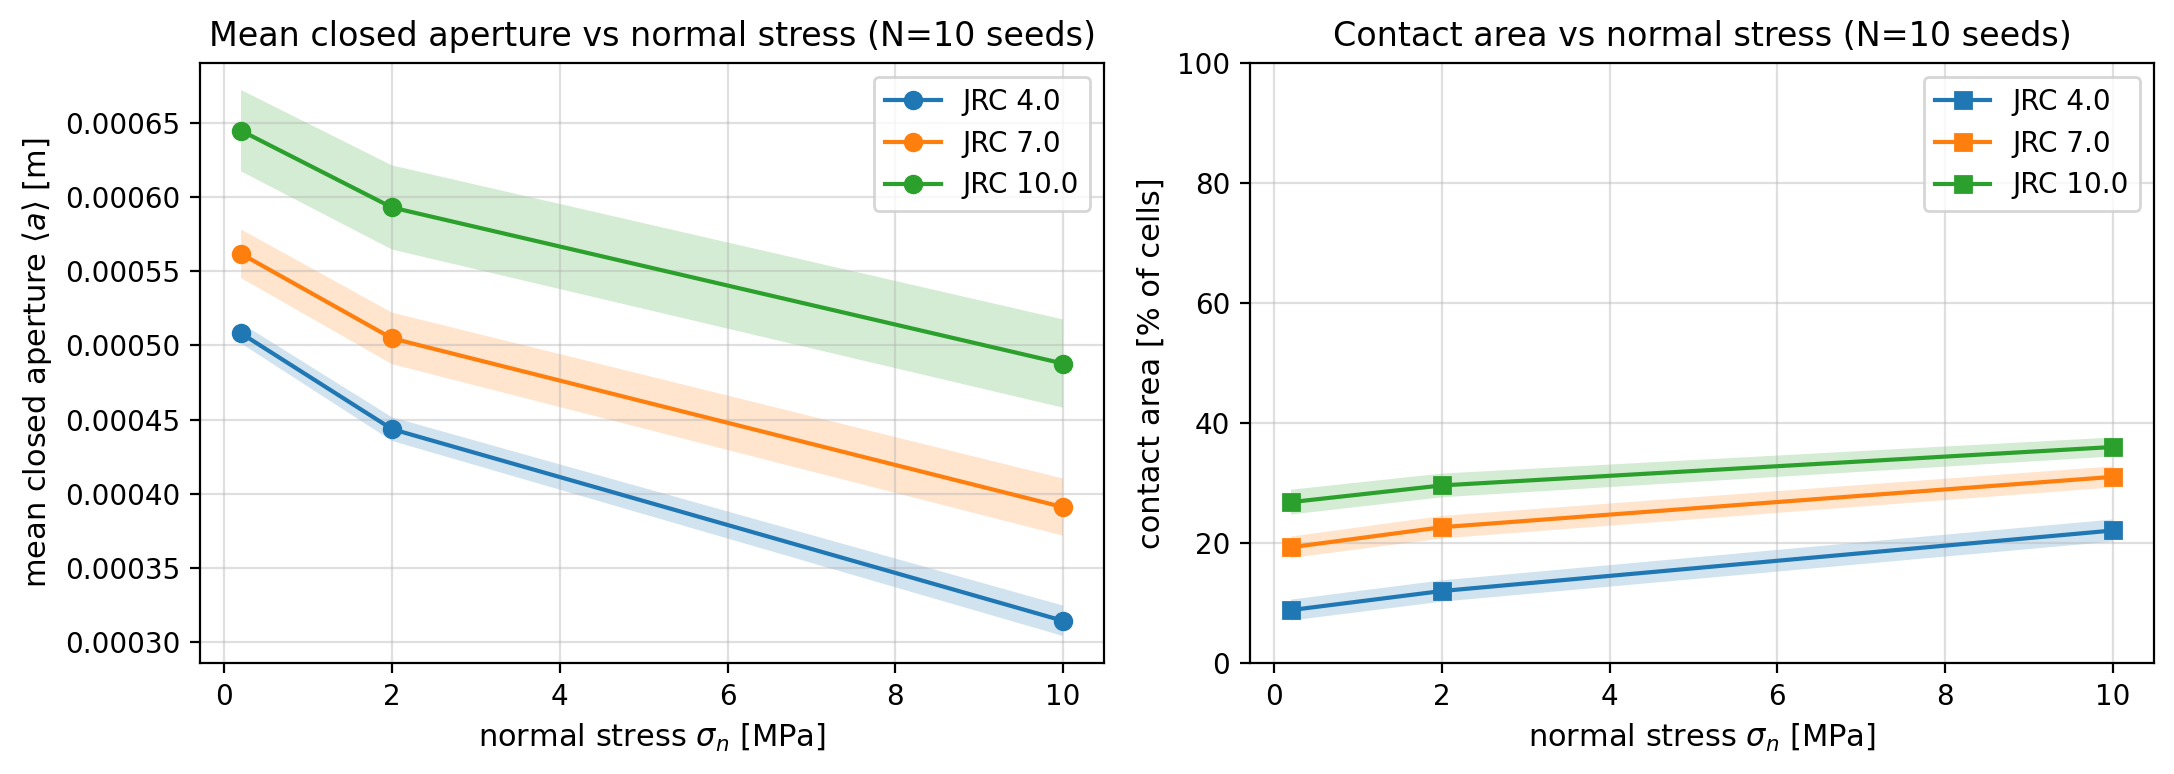


Done. Results written under: /Volumes/Projects/RiskXclude/roughfracture/_out_sigma_jrc_multi_seed
All-cases midline grid plot: _out_sigma_jrc_multi_seed/ALL_CASES_midline_profiles_grid.png


In [5]:
# ============================================================
# MAIN (Option 2: multiple seeds per JRC, sigma sweep per seed)
# ============================================================
if __name__ == "__main__":

    JRC_LIST = CFG["jrc"]
    SIGMAS_MPA = CFG["sigmas_mpa"]

    N_SEEDS = int(CFG.get("n_seeds", 10))
    SEED_BASE = int(CFG.get("seed", 123))
    SEED_LIST = [SEED_BASE + i for i in range(N_SEEDS)]

    out_root = Path(CFG.get("out_root", "_out_sigma_jrc_multi_seed"))
    out_root.mkdir(exist_ok=True)

    PLOT_PANELS_PER_SEED = bool(CFG.get("plot_panels_per_seed", False))

    stats = {
        "mean_raw": {},
        "mean_closed": {},
        "contact_raw_pct": {},
        "contact_closed_pct": {},
        "delta_bn": {},
        "dzmax": {},
    }
    stats_seed = {k: {} for k in stats.keys()}

    lines = {}          # lines[(jrc, sigma)] = list of midline arrays (one per seed)
    x_cells_ref = None  # reference x grid

    for jrc in JRC_LIST:
        print("\n" + "=" * 80)
        print(f"JRC = {jrc}   (replicates: {N_SEEDS} seeds)")
        print("=" * 80)

        for sigma_n in SIGMAS_MPA:
            key_js = (float(jrc), float(sigma_n))
            for k in stats.keys():
                stats[k].setdefault(key_js, [])

        for seed in SEED_LIST:
            print("\n" + "-" * 80)
            print(f"JRC={jrc}  |  seed={seed}")
            print("-" * 80)

            x, y, z_lower, z_upper = generate_correlated_surfaces(
                jrc=jrc,
                seed=seed,
                lambda_min=CFG["lambda_min"],
                lambda_max=CFG["lambda_max"],
                b0=CFG["b0"],
            )

            x_cells = 0.5 * (x[:-1] + x[1:])
            y_cells = 0.5 * (y[:-1] + y[1:])
            j_mid_cell = (len(y_cells) - 1) // 2
            y_mid_value = y_cells[j_mid_cell]
            Xc, Yc = np.meshgrid(x_cells, y_cells, indexing="ij")

            if x_cells_ref is None:
                x_cells_ref = x_cells.copy()

            base_mesh, x_cells_vtu, y_cells_vtu = build_quad_mesh_vtu(x, y, z0=0.0)
            assert np.allclose(x_cells, x_cells_vtu)
            assert np.allclose(y_cells, y_cells_vtu)

            a_closed_by_sigma = {}

            for sigma_n in SIGMAS_MPA:
                print(f"\n--- JRC={jrc}, seed={seed}, σ_n={sigma_n} MPa ---")

                if CFG["damage_wall"] == "upper":
                    z_dmg = casagrande_shear_v3(
                        surface=z_upper,
                        sigma_n_mpa=sigma_n,
                        dx=CFG["dx"], dy=CFG["dy"],
                        direction=CFG["direction"],
                        b_step_deg=CFG["b_step_deg"],
                        max_outer=CFG["max_outer"],
                        verbose=CFG["verbose"],
                    )
                    dzmax = float(np.max(np.abs(z_dmg - z_upper)))

                    if CFG["direction"] == "x":
                        z_up_slid = slide_upper_one_cell_x(z_dmg)
                    elif CFG["direction"] == "y":
                        z_up_slid = slide_upper_one_cell_y(z_dmg)
                    else:
                        raise ValueError("CFG['direction'] must be 'x' or 'y'")

                    a_raw = compute_midplane_aperture(z_lower, z_up_slid, CFG["dx"], CFG["dy"])

                elif CFG["damage_wall"] == "lower":
                    z_dmg = casagrande_shear_v3(
                        surface=z_lower,
                        sigma_n_mpa=sigma_n,
                        dx=CFG["dx"], dy=CFG["dy"],
                        direction=CFG["direction"],
                        b_step_deg=CFG["b_step_deg"],
                        max_outer=CFG["max_outer"],
                        verbose=CFG["verbose"],
                    )
                    dzmax = float(np.max(np.abs(z_dmg - z_lower)))

                    if CFG["direction"] == "x":
                        z_up_slid = slide_upper_one_cell_x(z_upper)
                    elif CFG["direction"] == "y":
                        z_up_slid = slide_upper_one_cell_y(z_upper)
                    else:
                        raise ValueError("CFG['direction'] must be 'x' or 'y'")

                    a_raw = compute_midplane_aperture(z_dmg, z_up_slid, CFG["dx"], CFG["dy"])

                else:
                    raise ValueError("CFG['damage_wall'] must be 'upper' or 'lower'")

                contact_raw_pct = float(np.mean(a_raw <= 0.0) * 100.0)

                a_cl, delta_b_n = apply_bandis_normal_closure(a_raw, sigma_n, b0=CFG["b0"])
                contact_closed_pct = float(np.mean(a_cl <= 0.0) * 100.0)

                mean_raw = float(a_raw.mean())
                mean_closed = float(a_cl.mean())

                print(f"  max |Δz|          = {dzmax:.3e} m")
                print(f"  mean(a_raw)       = {mean_raw:.3e} m")
                print(f"  contact_raw%      = {contact_raw_pct:6.2f} %")
                print(f"  Δb_n (Bandis)     = {float(delta_b_n):.3e} m")
                print(f"  mean(a_closed)    = {mean_closed:.3e} m")
                print(f"  contact_closed%   = {contact_closed_pct:6.2f} %")

                # Reynolds number validity check
                grad_p = 200.0 / CFG["lx"]   # ΔP/L [Pa/m] — OGS benchmark default
                re = compute_reynolds(a_cl, grad_p=grad_p)
                print_reynolds_report(re, label=f"JRC={jrc} seed={seed} σ_n={sigma_n} MPa")

                key_js = (float(jrc), float(sigma_n))
                stats["mean_raw"][key_js].append(mean_raw)
                stats["mean_closed"][key_js].append(mean_closed)
                stats["contact_raw_pct"][key_js].append(contact_raw_pct)
                stats["contact_closed_pct"][key_js].append(contact_closed_pct)
                stats["delta_bn"][key_js].append(float(delta_b_n))
                stats["dzmax"][key_js].append(float(dzmax))

                key_jss = (float(jrc), int(seed), float(sigma_n))
                stats_seed["mean_raw"][key_jss] = mean_raw
                stats_seed["mean_closed"][key_jss] = mean_closed
                stats_seed["contact_raw_pct"][key_jss] = contact_raw_pct
                stats_seed["contact_closed_pct"][key_jss] = contact_closed_pct
                stats_seed["delta_bn"][key_jss] = float(delta_b_n)
                stats_seed["dzmax"][key_jss] = float(dzmax)

                lines.setdefault(key_js, []).append(a_cl[:, j_mid_cell].copy())

                case_dir = out_root / f"JRC_{jrc}" / f"seed_{seed}" / f"sigma_{fmt_sigma_tag(sigma_n)}"
                case_dir.mkdir(parents=True, exist_ok=True)


                mesh = base_mesh.copy(deep=True)
                mesh.cell_data["aperture_raw"]    = a_raw.ravel(order="C")
                mesh.cell_data["aperture_closed"] = a_cl.ravel(order="C")
                
                # contact from the *raw closed aperture* definition
                tol = float(CFG.get("contact_tol", 0.0))
                
                contact = (a_cl <= tol).astype(np.uint8)
                open_   = (a_cl >  tol).astype(np.uint8)
                mesh.cell_data["contact"] = contact.ravel(order="C")
                
                # flow-safe aperture and cubic-law permeability k = a²/12
                # NOTE (Point 5 – friend review):
                #   k = a²/12 is the parallel-plate (cubic law) approximation.
                #   Known limitations:
                #     - ignores surface roughness / tortuosity (overestimates k)
                #     - ignores contact-area flow barriers
                #     - strictly valid only for Re << 1 (Darcy regime)
                #   Acceptable for a benchmark; use Forchheimer or roughness-
                #   corrected transmissivity for quantitative flow predictions.
                a_pos = np.maximum(a_cl, 0.0)
                mesh.cell_data["aperture_pos"] = a_pos.ravel(order="C")
                mesh.cell_data["k_frac"] = ((a_pos ** 2) / 12.0).ravel(order="C")
                
                mesh.save(case_dir / "fracture_aperture_k.vtu")


                a_closed_by_sigma[float(sigma_n)] = a_cl

            if PLOT_PANELS_PER_SEED:
                all_vals = np.concatenate([a_closed_by_sigma[float(s)].ravel() for s in SIGMAS_MPA])
                amin, amax = 0.0, float(np.max(all_vals))

                n_sigma = len(SIGMAS_MPA)
                fig = plt.figure(figsize=(13, 4 * n_sigma))
                gs = mpl.gridspec.GridSpec(n_sigma, 3, width_ratios=[1.0, 1.1, 0.8], wspace=0.35, hspace=0.35)

                im_for_cbar = None
                stride = CFG["stride"]

                for row, sigma_n in enumerate(SIGMAS_MPA):
                    a_cl = a_closed_by_sigma[float(sigma_n)]

                    ax2d = fig.add_subplot(gs[row, 0])
                    im = ax2d.imshow(
                        a_cl.T, origin="lower",
                        extent=(x_cells[0], x_cells[-1], y_cells[0], y_cells[-1]),
                        aspect="equal", vmin=amin, vmax=amax, cmap="viridis",
                    )
                    if im_for_cbar is None:
                        im_for_cbar = im
                    ax2d.axhline(y_mid_value, color="white", linestyle="--", linewidth=1.0)
                    if row == 0:
                        ax2d.set_title("Closed aperture (2D map)")
                    ax2d.set_xlabel("x [m]")
                    ax2d.set_ylabel("y [m]")
                    ax2d.text(
                        0.02, 0.95, fr"JRC={jrc}, seed={seed}, σₙ={sigma_n} MPa",
                        transform=ax2d.transAxes, ha="left", va="top",
                        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, linewidth=0.0),
                    )

                    ax3d = fig.add_subplot(gs[row, 1], projection="3d")
                    ax3d.plot_surface(
                        Xc[::stride, ::stride], Yc[::stride, ::stride], a_cl[::stride, ::stride],
                        rstride=1, cstride=1, linewidth=0, antialiased=True,
                        cmap="viridis", vmin=amin, vmax=amax,
                    )
                    ax3d.plot(
                        x_cells, np.full_like(x_cells, y_mid_value), a_cl[:, j_mid_cell],
                        color="white", linestyle="--", linewidth=3,
                    )
                    ax3d.set_xlim(x_cells[0], x_cells[-1])
                    ax3d.set_ylim(y_cells[0], y_cells[-1])
                    ax3d.set_zlim(amin, amax)
                    ax3d.set_xlabel("x [m]")
                    ax3d.set_ylabel("y [m]")
                    ax3d.set_zlabel("a [m]")
                    ax3d.view_init(elev=35, azim=-135)
                    if row == 0:
                        ax3d.set_title("Closed aperture (3D surface)")

                    ax1d = fig.add_subplot(gs[row, 2])
                    ax1d.plot(x_cells, a_cl[:, j_mid_cell], lw=1.5)
                    ax1d.set_xlim(x_cells[0], x_cells[-1])
                    ax1d.set_ylim(amin, amax)
                    ax1d.set_xlabel("x [m]")
                    if row == 0:
                        ax1d.set_title(fr"Cross-section at $y \approx {y_mid_value:.2f}\,\mathrm{{m}}$")
                    ax1d.set_ylabel("a [m]")
                    ax1d.grid(True, alpha=0.4)

                cbar_ax = fig.add_axes([0.20, 0.04, 0.60, 0.02])
                cbar = fig.colorbar(im_for_cbar, cax=cbar_ax, orientation="horizontal")
                cbar.set_label("closed aperture along midplane a [m]")

                fig.suptitle(f"Closed aperture fields (JRC={jrc}, seed={seed}) for different normal stresses", y=0.99)
                plt.tight_layout(rect=[0.03, 0.08, 0.97, 0.96])

                fig_out = out_root / f"JRC_{jrc}" / f"seed_{seed}" / f"aperture_panels_JRC_{jrc}_seed_{seed}.png"
                fig.savefig(fig_out, dpi=200)
                plt.close(fig)

    out_all = plot_all_cases_midline_profiles_grid(
        lines=lines,
        x_cells=x_cells_ref,
        jrc_list=JRC_LIST,
        sigmas_mpa=SIGMAS_MPA,
        out_png=out_root / "ALL_CASES_midline_profiles_grid.png",
        n_seeds=N_SEEDS,
        qband=(0.10, 0.90),
        show_seed_lines=True,
    )

    fig2, axes = plt.subplots(1, 2, figsize=(11, 4))
    sig_arr = np.array(SIGMAS_MPA, dtype=float)

    for jrc in JRC_LIST:
        mean_mu = []
        mean_sd = []
        contact_mu = []
        contact_sd = []

        for s in SIGMAS_MPA:
            key_js = (float(jrc), float(s))
            vals_mean = np.array(stats["mean_closed"][key_js], dtype=float)
            vals_contact = np.array(stats["contact_closed_pct"][key_js], dtype=float)

            mean_mu.append(vals_mean.mean())
            mean_sd.append(vals_mean.std(ddof=1) if len(vals_mean) > 1 else 0.0)

            contact_mu.append(vals_contact.mean())
            contact_sd.append(vals_contact.std(ddof=1) if len(vals_contact) > 1 else 0.0)

        mean_mu = np.array(mean_mu)
        mean_sd = np.array(mean_sd)
        contact_mu = np.array(contact_mu)
        contact_sd = np.array(contact_sd)

        axes[0].plot(sig_arr, mean_mu, marker="o", lw=1.5, label=f"JRC {jrc}")
        axes[0].fill_between(sig_arr, mean_mu - mean_sd, mean_mu + mean_sd, alpha=0.2)

        axes[1].plot(sig_arr, contact_mu, marker="s", lw=1.5, label=f"JRC {jrc}")
        axes[1].fill_between(sig_arr, contact_mu - contact_sd, contact_mu + contact_sd, alpha=0.2)

    axes[0].set_xlabel(r"normal stress $\sigma_n$ [MPa]")
    axes[0].set_ylabel(r"mean closed aperture $\langle a \rangle$ [m]")
    axes[0].set_title(f"Mean closed aperture vs normal stress (N={N_SEEDS} seeds)")
    axes[0].grid(True, alpha=0.4)
    axes[0].legend()

    axes[1].set_xlabel(r"normal stress $\sigma_n$ [MPa]")
    axes[1].set_ylabel("contact area [% of cells]")
    axes[1].set_title(f"Contact area vs normal stress (N={N_SEEDS} seeds)")
    axes[1].set_ylim(0.0, 100.0)
    axes[1].grid(True, alpha=0.4)
    axes[1].legend()

    fig2.tight_layout()
    fig2.savefig(out_root / "summary_mean_contact_vs_sigma_by_JRC_multi_seed.png", dpi=200)
    plt.show()

    print(f"\nDone. Results written under: {out_root.resolve()}")
    print(f"All-cases midline grid plot: {out_all}")

[scan] found VTUs=120 | indexed=120 | skipped=0
  example: (10.0, 123, 0.2) -> _out_sigma_jrc_multi_seed/JRC_10.0/seed_123/sigma_0p2MPa/fracture_aperture_k.vtu
  example: (10.0, 123, 2.0) -> _out_sigma_jrc_multi_seed/JRC_10.0/seed_123/sigma_2MPa/fracture_aperture_k.vtu
  example: (10.0, 123, 10.0) -> _out_sigma_jrc_multi_seed/JRC_10.0/seed_123/sigma_10MPa/fracture_aperture_k.vtu
  example: (10.0, 123, 5.0) -> _out_sigma_jrc_multi_seed/JRC_10.0/seed_123/sigma_5MPa/fracture_aperture_k.vtu
  example: (10.0, 124, 0.2) -> _out_sigma_jrc_multi_seed/JRC_10.0/seed_124/sigma_0p2MPa/fracture_aperture_k.vtu
JRCs : [4.0, 7.0, 10.0]
seeds: [123, 124, 125, 126, 127, 128, 129, 130, 131, 132]
sigmas: [0.2, 2.0, 5.0, 10.0]

Available cases (counts per seed):
  seed 123: 12 cases
  seed 124: 12 cases
  seed 125: 12 cases
  seed 126: 12 cases
  seed 127: 12 cases
  seed 128: 12 cases
  seed 129: 12 cases
  seed 130: 12 cases
  seed 131: 12 cases
  seed 132: 12 cases
 field='aperture_closed' vmin=0.000e+0

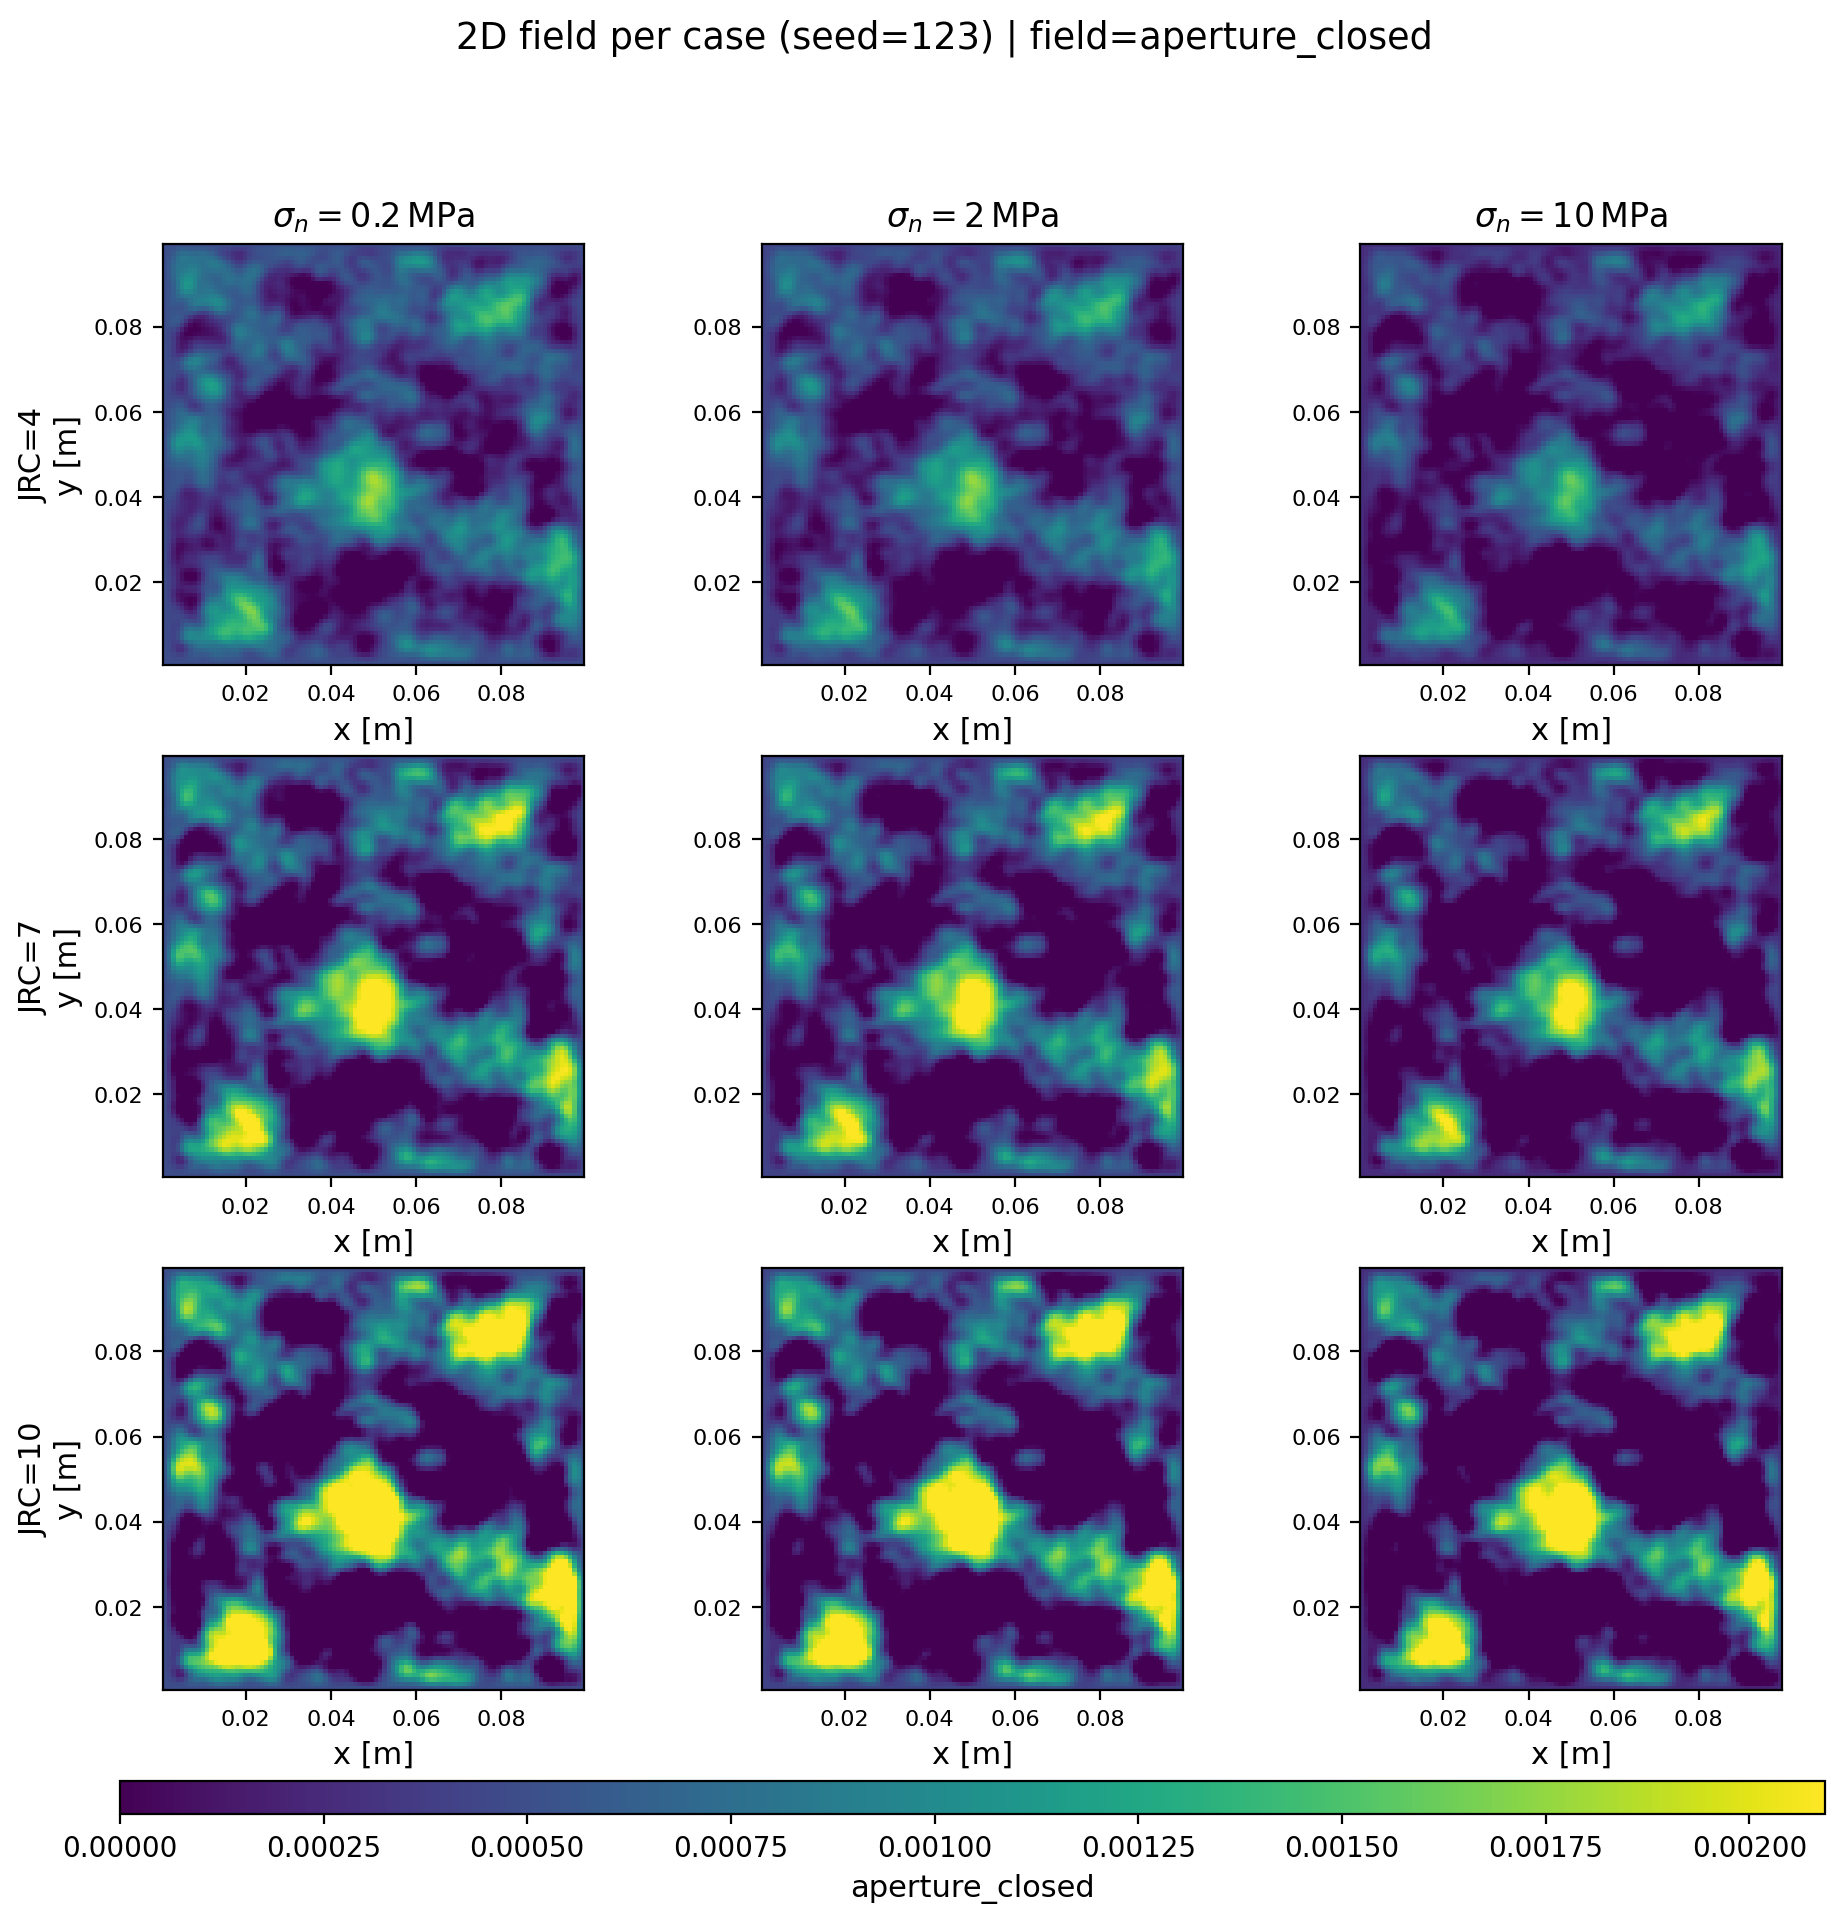

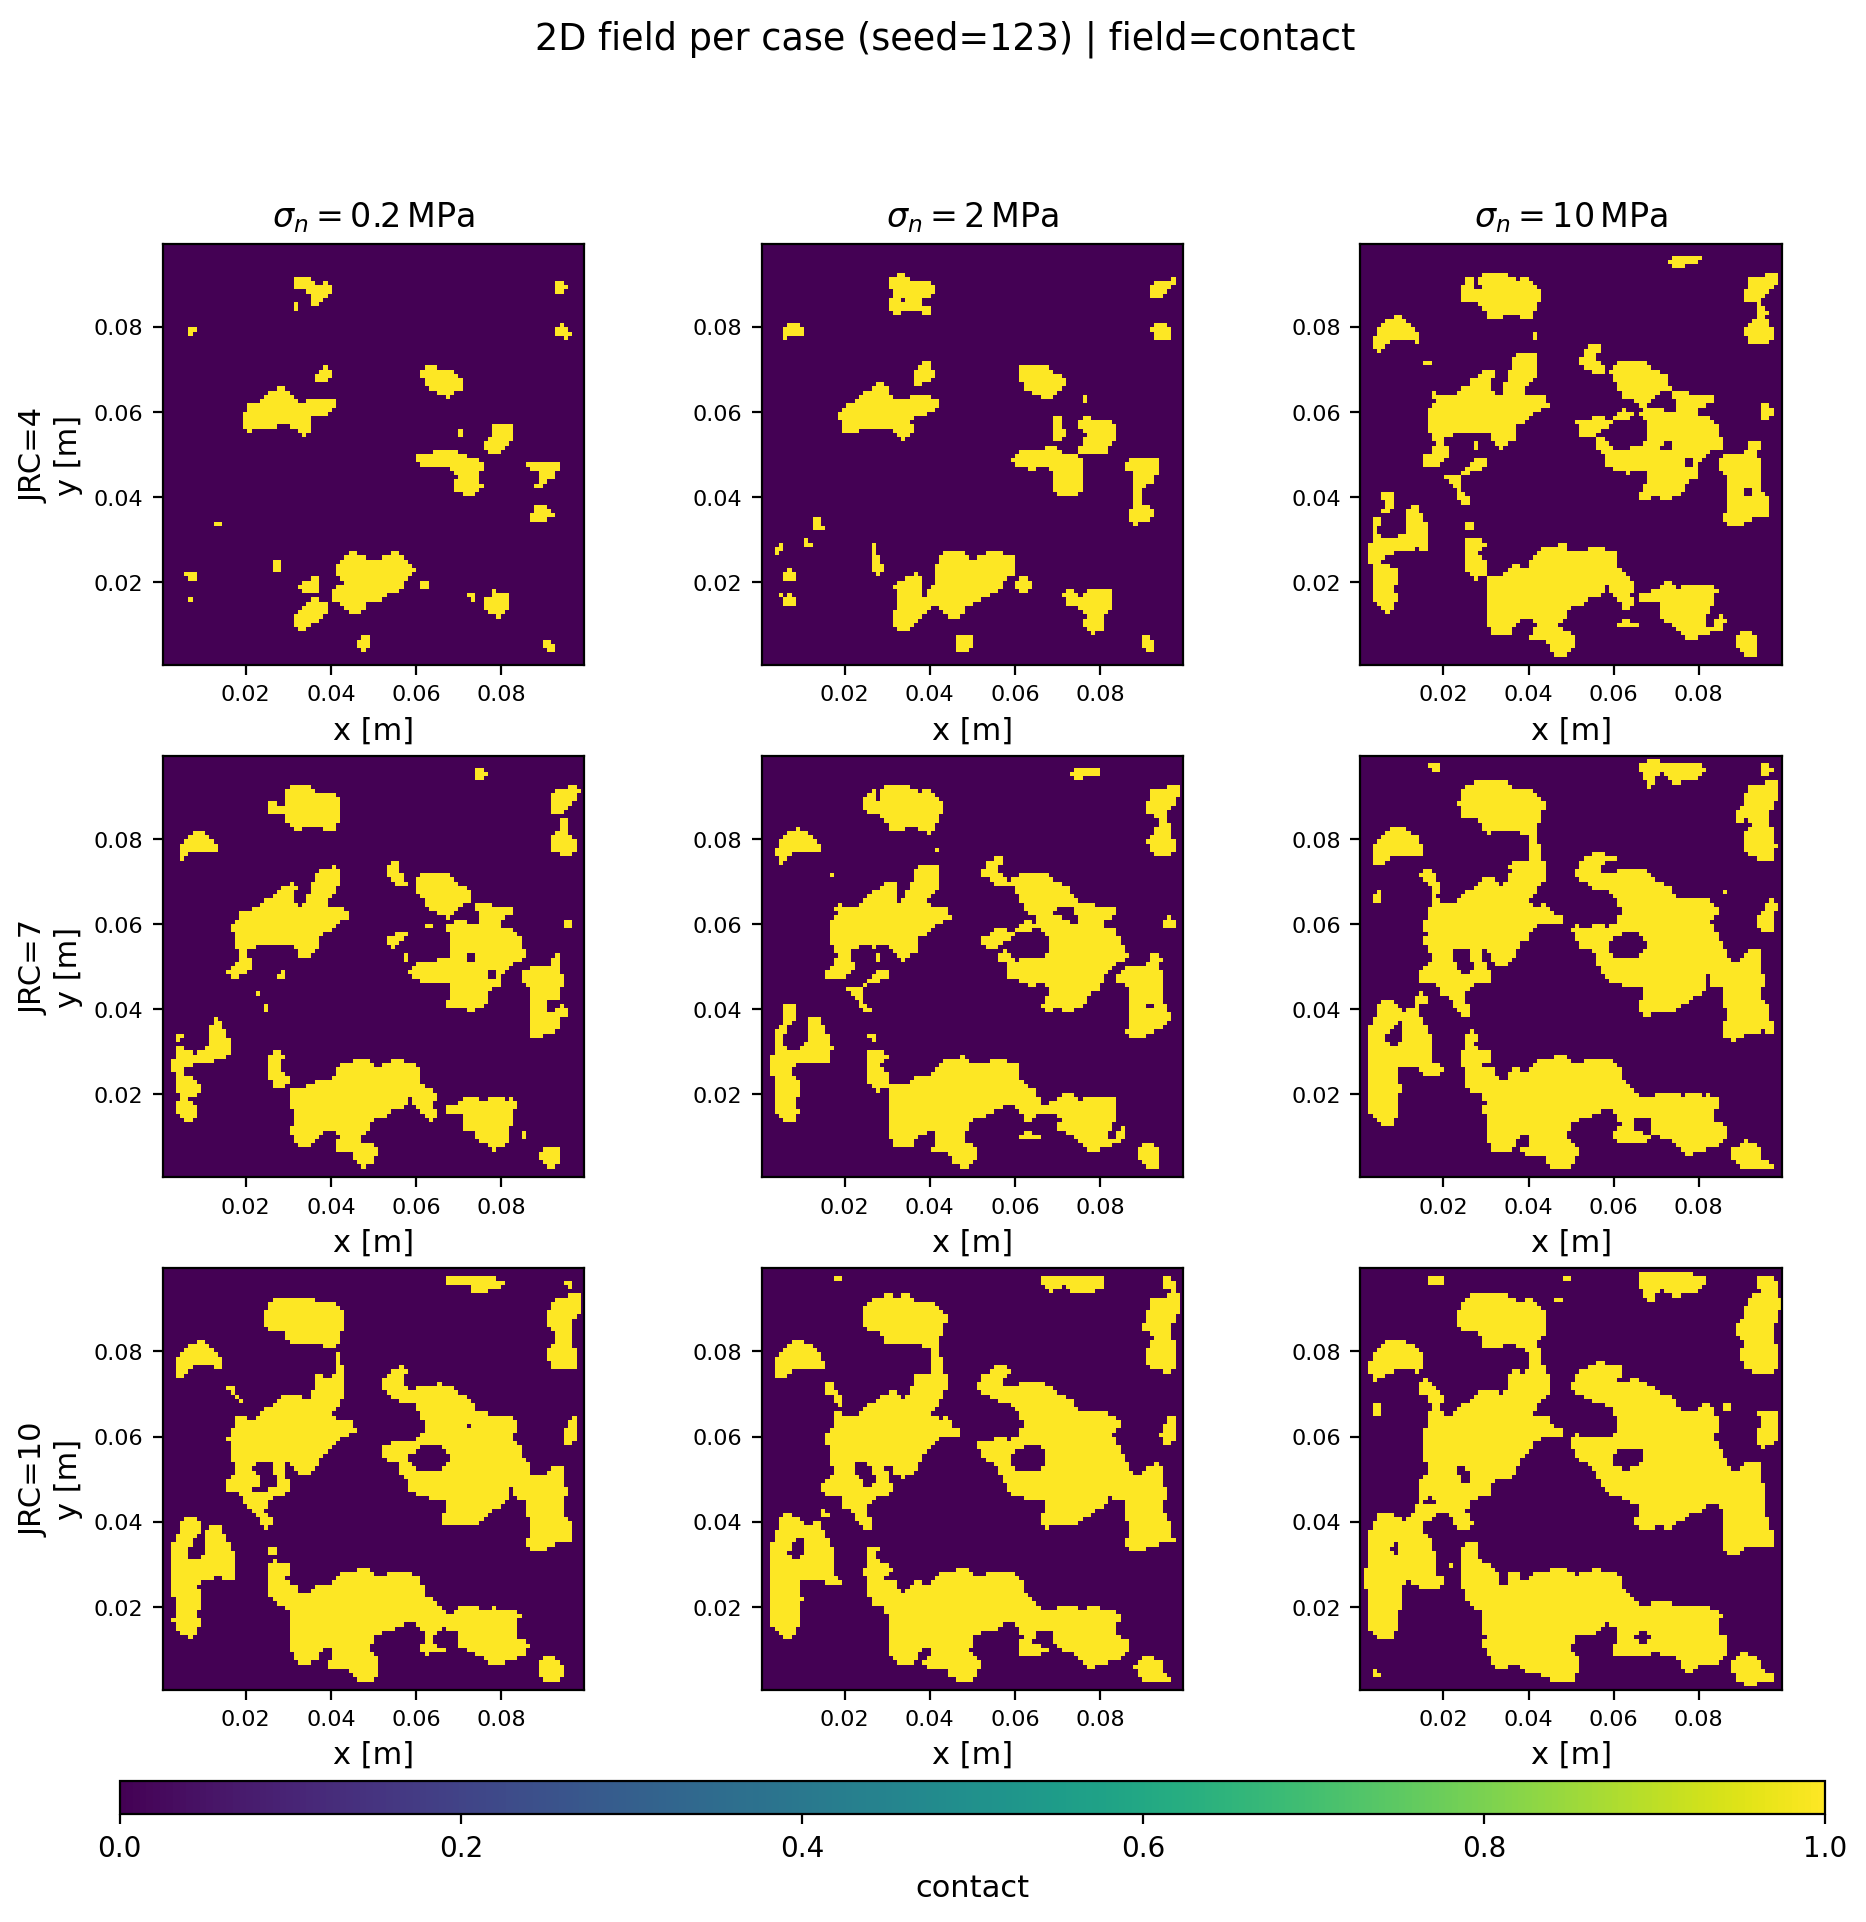

(0.0, 1.0)

In [6]:
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pyvista as pv

_RE_JRC  = re.compile(r"^JRC_([0-9]+(?:\.[0-9]+)?)$")
_RE_SEED = re.compile(r"^seed_(\d+)$")
_RE_SIG  = re.compile(r"^sigma_(.+)$")


def _parse_sigma_token(tok: str) -> float | None:
    t = tok.strip().lower()
    t = t.replace("mpa", "").replace("pa", "").replace("_", "")
    t = t.replace("p", ".")
    t = re.sub(r"[^0-9eE\+\-\.]", "", t)
    try:
        return float(t)
    except Exception:
        return None


def scan_vtu_index(out_root: str | Path, filename: str = "fracture_aperture_k.vtu") -> dict:
    out_root = Path(out_root)
    vtus = list(out_root.rglob(filename))
    if not vtus:
        raise FileNotFoundError(f"No '{filename}' found under: {out_root}")

    idx = {}
    bad = 0

    for vtu in vtus:
        try:
            sigma_dir = vtu.parent.name
            seed_dir  = vtu.parent.parent.name
            jrc_dir   = vtu.parent.parent.parent.name

            mj = _RE_JRC.match(jrc_dir)
            ms = _RE_SEED.match(seed_dir)
            mk = _RE_SIG.match(sigma_dir)
            if not (mj and ms and mk):
                bad += 1
                continue

            jrc  = float(mj.group(1))
            seed = int(ms.group(1))
            sigma = _parse_sigma_token(mk.group(1))
            if sigma is None:
                bad += 1
                continue

            idx[(jrc, seed, sigma)] = vtu
        except Exception:
            bad += 1

    if not idx:
        raise ValueError(f"Found {len(vtus)} VTUs but could not parse any case. Example: {vtus[0]}")

    print(f"[scan] found VTUs={len(vtus)} | indexed={len(idx)} | skipped={bad}")
    for k, p in list(idx.items())[:5]:
        print("  example:", k, "->", p)
    return idx


def summarize_index(idx: dict):
    jrcs  = sorted({k[0] for k in idx})
    seeds = sorted({k[1] for k in idx})
    sigs  = sorted({k[2] for k in idx})
    print("JRCs :", jrcs)
    print("seeds:", seeds)
    print("sigmas:", sigs)
    print("\nAvailable cases (counts per seed):")
    for seed in seeds:
        c = sum(1 for (_, s, _) in idx if s == seed)
        print(f"  seed {seed}: {c} cases")


def read_field_2d(vtu_path: Path, field: str):
    m = pv.read(vtu_path)
    if field not in m.cell_data:
        raise KeyError(f"Field '{field}' not in {vtu_path}. Available: {list(m.cell_data.keys())}")

    vals = np.asarray(m.cell_data[field], dtype=float)
    cc = m.cell_centers().points

    x = cc[:, 0]
    y = cc[:, 1]
    order = np.lexsort((y, x))

    x_s = x[order]
    y_s = y[order]
    v_s = vals[order]

    xu = np.unique(np.round(x_s, 12))
    yu = np.unique(np.round(y_s, 12))
    nx, ny = len(xu), len(yu)

    if nx * ny != v_s.size:
        raise ValueError(f"Cannot reshape {v_s.size} cells into nx*ny = {nx}*{ny}")

    V = v_s.reshape(nx, ny, order="C")
    return V, xu, yu


def compute_global_vmin_vmax(idx: dict, field: str, clip=(0.01, 0.99), force_vmin0=True):
    vals_all = []
    for _, vtu in idx.items():
        m = pv.read(vtu)
        if field not in m.cell_data:
            continue
        a = np.asarray(m.cell_data[field], dtype=float)
        a = a[np.isfinite(a)]
        if a.size:
            vals_all.append(a)

    if not vals_all:
        raise ValueError(f"No finite values found for field='{field}' across indexed VTUs.")

    allv = np.concatenate(vals_all)
    lo = float(np.quantile(allv, clip[0]))
    hi = float(np.quantile(allv, clip[1]))
    if force_vmin0:
        lo = 0.0

    print(f" field='{field}' vmin={lo:.3e}, vmax={hi:.3e}")
    return lo, hi


def get_contact_field_from_aperture(V_aperture: np.ndarray) -> np.ndarray:
    return (V_aperture <= 0.0).astype(float)


def plot_seed_grid_field_2d(
    idx: dict,
    seed: int,
    jrc_list: list,
    sigmas_mpa: list,
    field: str,
    *,
    vmin: float | None = None,
    vmax: float | None = None,
    clip=(0.01, 0.99),
    force_vmin0=False,
    compute_if_missing: bool = True,
    save_png: str | Path | None = None,
):
    jrc_list = [float(j) for j in jrc_list]
    sigmas_mpa = [float(s) for s in sigmas_mpa]

    if vmin is None or vmax is None:
        if field == "contact":
            vmin, vmax = 0.0, 1.0
        else:
            vmin, vmax = compute_global_vmin_vmax(idx, field=field, clip=clip, force_vmin0=force_vmin0)

    nrows = len(jrc_list)
    ncols = len(sigmas_mpa)

    fig = plt.figure(figsize=(3.2 * ncols + 1.4, 3.0 * nrows + 1.2))
    gs = fig.add_gridspec(
        nrows + 1, ncols,
        height_ratios=[1.0] * nrows + [0.08],
        hspace=0.28, wspace=0.18
    )

    im0 = None

    for r, jrc in enumerate(jrc_list):
        for c, sigma in enumerate(sigmas_mpa):
            ax = fig.add_subplot(gs[r, c])

            key = (float(jrc), int(seed), float(sigma))
            if key not in idx:
                ax.set_axis_off()
                continue

            vtu = idx[key]

            try:
                V, xu, yu = read_field_2d(vtu, field)
            except KeyError:
                if not compute_if_missing:
                    ax.set_axis_off()
                    continue
                if field == "contact":
                    Vap, xu, yu = read_field_2d(vtu, "aperture_closed")
                    V = get_contact_field_from_aperture(Vap)
                else:
                    raise

            im = ax.imshow(
                V.T, origin="lower", aspect="equal",
                extent=(xu[0], xu[-1], yu[0], yu[-1]),
                vmin=vmin, vmax=vmax
            )
            if im0 is None:
                im0 = im

            if r == 0:
                ax.set_title(rf"$\sigma_n = {sigma:g}\,\mathrm{{MPa}}$")
            if c == 0:
                ax.set_ylabel(f"JRC={jrc:g}\ny [m]")
            ax.set_xlabel("x [m]")
            ax.tick_params(labelsize=8)

    cax = fig.add_subplot(gs[-1, :])
    if im0 is not None:
        cbar = fig.colorbar(im0, cax=cax, orientation="horizontal")
        cbar.set_label(f"{field}")

    fig.suptitle(f"2D field per case (seed={seed}) | field={field}", y=0.99)

    if save_png is not None:
        save_png = Path(save_png)
        save_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_png, dpi=220, bbox_inches="tight")

    plt.show()
    return (vmin, vmax)


# =========================
# USAGE
# =========================
# out_root, SEED_LIST, JRC_LIST, SIGMAS_MPA must already exist in your notebook/kernel

idx = scan_vtu_index(out_root)
summarize_index(idx)

vmin_a, vmax_a = compute_global_vmin_vmax(idx, field="aperture_closed", clip=(0.01, 0.99), force_vmin0=True)

plot_seed_grid_field_2d(
    idx=idx,
    seed=int(SEED_LIST[0]),
    jrc_list=JRC_LIST,
    sigmas_mpa=SIGMAS_MPA,
    field="aperture_closed",
    vmin=vmin_a, vmax=vmax_a,
    save_png=Path(out_root) / "_whole_model_2D" / f"seed_{int(SEED_LIST[0])}_aperture_closed.png",
)

plot_seed_grid_field_2d(
    idx=idx,
    seed=int(SEED_LIST[0]),
    jrc_list=JRC_LIST,
    sigmas_mpa=SIGMAS_MPA,
    field="contact",
    vmin=0.0, vmax=1.0,
    save_png=Path(out_root) / "_whole_model_2D" / f"seed_{int(SEED_LIST[0])}_contact.png",
)


# Save the upper and lower surfaces in VTK format for specific $\sigma_n$ just for visualization (constant seed)

In [15]:
VTK_TRIANGLE = np.uint8(5)
VTK_QUAD     = np.uint8(9)


def write_vtu_joint_2d_midplane(
    x,
    y,
    z_lower,
    z_upper,
    aperture_raw,                 # (nx-1, ny-1)  BEFORE closure
    vtu_filename: str,
    aperture_closed=None,         # (nx-1, ny-1)  AFTER closure (optional but recommended)
    element: str = "tri",         # "tri" or "quad"
    split: str = "checkerboard",  # "fixed" | "checkerboard" | "best"   (tri only)
    contact_tol: float = 1e-12,
    eps_log: float = 1e-15,
    # Optional metadata (stored in field_data)
    meta: dict | None = None,
    # Optional: store permeability from closed aperture (k=a^2/12)
    store_k_frac: bool = True,
):
    """
    Export a MIDPLANE 2D surface mesh as VTU (UnstructuredGrid).

    Geometry:
      points: z_mid_node = 0.5*(z_lower + z_upper)

    Required cell data:
      - aperture_raw  (from aperture_raw)
      - contact_raw   (aperture_raw <= contact_tol)
      - open_raw
      - log_aperture_raw

    If aperture_closed is provided:
      - aperture_closed
      - contact_closed
      - open_closed
      - log_aperture_closed
      - (optional) k_frac = aperture_closed^2 / 12

    Also stores point_data:
      - grid_id, grid_i, grid_j
      - z_lower_pt, z_upper_pt, z_mid_pt

    Stores field_data:
      - nx, ny
      - and anything in meta (e.g., jrc, sigma_mpa, b0, lambda_min/max, seed, etc.)
    """

    x = np.asarray(x, float)
    y = np.asarray(y, float)
    z_lower = np.asarray(z_lower, float)
    z_upper = np.asarray(z_upper, float)
    aperture_raw = np.asarray(aperture_raw, float)

    nx, ny = x.size, y.size
    if z_lower.shape != (nx, ny):
        raise ValueError(f"z_lower shape mismatch: {z_lower.shape} != ({nx},{ny})")
    if z_upper.shape != (nx, ny):
        raise ValueError(f"z_upper shape mismatch: {z_upper.shape} != ({nx},{ny})")
    if aperture_raw.shape != (nx - 1, ny - 1):
        raise ValueError(f"aperture_raw shape mismatch: {aperture_raw.shape} != ({nx-1},{ny-1})")

    if aperture_closed is not None:
        aperture_closed = np.asarray(aperture_closed, float)
        if aperture_closed.shape != (nx - 1, ny - 1):
            raise ValueError(f"aperture_closed shape mismatch: {aperture_closed.shape} != ({nx-1},{ny-1})")

    element = element.lower().strip()
    split = split.lower().strip()
    if element not in ("tri", "quad"):
        raise ValueError("element must be 'tri' or 'quad'")
    if split not in ("fixed", "checkerboard", "best"):
        raise ValueError("split must be 'fixed', 'checkerboard', or 'best' (for tri).")

    # ---- 1) midplane node z
    z_mid_node = 0.5 * (z_lower + z_upper)

    # ---- points in pid order: pid(i,j)=i+nx*j (j outer, i inner)
    pts = np.empty((nx * ny, 3), float)
    k = 0
    for j in range(ny):
        for i in range(nx):
            pts[k, 0] = x[i]
            pts[k, 1] = y[j]
            pts[k, 2] = z_mid_node[i, j]
            k += 1

    def pid(i, j):
        return i + nx * j

    # ---- cell-wise fields (RAW)
    contact_raw = (aperture_raw <= float(contact_tol)).astype(np.int32)
    open_raw    = (1 - contact_raw).astype(np.int32)
    log_raw     = np.log10(np.maximum(aperture_raw, 0.0) + float(eps_log))

    # ---- cell-wise fields (CLOSED)
    if aperture_closed is not None:
        contact_closed = (aperture_closed <= float(contact_tol)).astype(np.int32)
        open_closed    = (1 - contact_closed).astype(np.int32)
        log_closed     = np.log10(np.maximum(aperture_closed, 0.0) + float(eps_log))
        if store_k_frac:
            k_frac = (np.maximum(aperture_closed, 0.0) ** 2) / 12.0  # [m^2]
    else:
        contact_closed = open_closed = log_closed = k_frac = None

    # ---- helpers for "best" split + CCW orientation (in XY)
    def tri_normal(pA, pB, pC):
        v1 = pB - pA
        v2 = pC - pA
        n = np.cross(v1, v2)
        nn = np.linalg.norm(n)
        return n / nn if nn > 0 else n

    def normal_mismatch_for_split(t1, t2):
        n1 = tri_normal(pts[t1[0]], pts[t1[1]], pts[t1[2]])
        n2 = tri_normal(pts[t2[0]], pts[t2[1]], pts[t2[2]])
        d = abs(float(np.dot(n1, n2)))
        return 1.0 - d  # smaller is better

    def ensure_ccw_xy(a, b, c):
        Ax, Ay = pts[a, 0], pts[a, 1]
        Bx, By = pts[b, 0], pts[b, 1]
        Cx, Cy = pts[c, 0], pts[c, 1]
        area2 = (Bx - Ax) * (Cy - Ay) - (By - Ay) * (Cx - Ax)
        return (a, c, b) if area2 < 0 else (a, b, c)

    # ---- 2) build connectivity + duplicate parent-quad values per triangle
    cells = []
    celltypes = []

    raw_list = []
    cr_list  = []
    or_list  = []
    lraw_list = []

    if aperture_closed is not None:
        closed_list = []
        cc_list     = []
        oc_list     = []
        lcl_list    = []
        k_list      = [] if (store_k_frac and k_frac is not None) else None

    if element == "quad":
        for j in range(ny - 1):
            for i in range(nx - 1):
                p00 = pid(i,   j)
                p10 = pid(i+1, j)
                p11 = pid(i+1, j+1)
                p01 = pid(i,   j+1)

                cells.extend([4, p00, p10, p11, p01])
                celltypes.append(VTK_QUAD)

                raw_list.append(aperture_raw[i, j])
                cr_list.append(contact_raw[i, j])
                or_list.append(open_raw[i, j])
                lraw_list.append(log_raw[i, j])

                if aperture_closed is not None:
                    closed_list.append(aperture_closed[i, j])
                    cc_list.append(contact_closed[i, j])
                    oc_list.append(open_closed[i, j])
                    lcl_list.append(log_closed[i, j])
                    if k_list is not None:
                        k_list.append(k_frac[i, j])

    else:  # tri
        for j in range(ny - 1):
            for i in range(nx - 1):
                p00 = pid(i,   j)
                p10 = pid(i+1, j)
                p11 = pid(i+1, j+1)
                p01 = pid(i,   j+1)

                A1, A2 = (p00, p10, p11), (p00, p11, p01)  # diag 00-11
                B1, B2 = (p00, p10, p01), (p10, p11, p01)  # diag 10-01

                if split == "best":
                    use_A = normal_mismatch_for_split(A1, A2) <= normal_mismatch_for_split(B1, B2)
                elif split == "checkerboard":
                    use_A = ((i + j) % 2 == 0)
                else:
                    use_A = True

                tris = [A1, A2] if use_A else [B1, B2]

                for (a, b, c) in tris:
                    a, b, c = ensure_ccw_xy(a, b, c)

                    cells.extend([3, a, b, c])
                    celltypes.append(VTK_TRIANGLE)

                    # duplicate parent-quad values for each triangle
                    raw_list.append(aperture_raw[i, j])
                    cr_list.append(contact_raw[i, j])
                    or_list.append(open_raw[i, j])
                    lraw_list.append(log_raw[i, j])

                    if aperture_closed is not None:
                        closed_list.append(aperture_closed[i, j])
                        cc_list.append(contact_closed[i, j])
                        oc_list.append(open_closed[i, j])
                        lcl_list.append(log_closed[i, j])
                        if k_list is not None:
                            k_list.append(k_frac[i, j])

    cells = np.array(cells, dtype=np.int64)
    celltypes = np.array(celltypes, dtype=np.uint8)

    ugrid = pv.UnstructuredGrid(cells, celltypes, pts)

    # ---- 3) point_data: structured indexing + walls
    grid_id = np.arange(nx * ny, dtype=np.int32)
    ugrid.point_data["grid_id"] = grid_id
    ugrid.point_data["grid_i"]  = (grid_id % nx).astype(np.int32)
    ugrid.point_data["grid_j"]  = (grid_id // nx).astype(np.int32)

    zL = np.empty(nx * ny, dtype=float)
    zU = np.empty(nx * ny, dtype=float)
    kk = 0
    for jj in range(ny):
        for ii in range(nx):
            zL[kk] = z_lower[ii, jj]
            zU[kk] = z_upper[ii, jj]
            kk += 1

    ugrid.point_data["z_lower_pt"] = zL
    ugrid.point_data["z_upper_pt"] = zU
    ugrid.point_data["z_mid_pt"]   = pts[:, 2].copy()

    # ---- 4) field_data: nx, ny + metadata
    ugrid.field_data["nx"] = np.array([nx], dtype=np.int32)
    ugrid.field_data["ny"] = np.array([ny], dtype=np.int32)
    if meta:
        for k, v in meta.items():
            # store scalars as 1-length arrays; strings as bytes
            if isinstance(v, str):
                ugrid.field_data[str(k)] = np.array([v.encode("utf-8")], dtype="|S256")
            else:
                ugrid.field_data[str(k)] = np.array([v], dtype=float)

    # ---- 5) cell_data (RAW + CLOSED)
    ugrid.cell_data["aperture_raw"] = np.asarray(raw_list, float)
    ugrid.cell_data["contact_raw"]  = np.asarray(cr_list, np.int32)
    ugrid.cell_data["open_raw"]     = np.asarray(or_list, np.int32)
    ugrid.cell_data["log_aperture_raw"] = np.asarray(lraw_list, float)

    if aperture_closed is not None:
        ugrid.cell_data["aperture_closed"] = np.asarray(closed_list, float)
        ugrid.cell_data["contact_closed"]  = np.asarray(cc_list, np.int32)
        ugrid.cell_data["open_closed"]     = np.asarray(oc_list, np.int32)
        ugrid.cell_data["log_aperture_closed"] = np.asarray(lcl_list, float)
        if k_list is not None:
            ugrid.cell_data["k_frac"] = np.asarray(k_list, float)

    # ---- 6) save
    Path(vtu_filename).parent.mkdir(parents=True, exist_ok=True)
    ugrid.save(vtu_filename)
    return str(vtu_filename)


def check_triangle_quality(vtu_file: str):
    g = pv.read(vtu_file)
    if g.n_cells == 0:
        print("No cells found.")
        return

    tri_ids = np.where(g.celltypes == VTK_TRIANGLE)[0]
    if tri_ids.size == 0:
        print("No triangles found (maybe you wrote quads).")
        return

    tri = g.extract_cells(tri_ids)
    pts = tri.points
    cells = tri.cells.reshape((-1, 4))[:, 1:]

    areas = []
    aspects = []
    for a, b, c in cells:
        A = pts[a]; B = pts[b]; C = pts[c]
        AB = np.linalg.norm(B - A)
        BC = np.linalg.norm(C - B)
        CA = np.linalg.norm(A - C)
        s = 0.5 * (AB + BC + CA)
        area = max(s*(s-AB)*(s-BC)*(s-CA), 0.0) ** 0.5
        areas.append(area)
        emax = max(AB, BC, CA)
        emin = max(min(AB, BC, CA), 1e-30)
        aspects.append(emax / emin)

    areas = np.array(areas)
    aspects = np.array(aspects)
    print(f"Triangles: {tri.n_cells}")
    print(f"Area min/median/max: {areas.min():.3e} / {np.median(areas):.3e} / {areas.max():.3e}")
    print(f"Aspect (maxEdge/minEdge) min/median/max: {aspects.min():.3f} / {np.median(aspects):.3f} / {aspects.max():.3f}")


In [16]:
def run_sigma_damage_lower_slide_upper_write_vtu(
    cfg: dict,
    sigma_n_mpa: float,
    out_dir: str | Path | None = None,
    element: str = "tri",
    split: str = "checkerboard",
):
    # Output path (unique per JRC + sigma)
    out_dir = Path(out_dir if out_dir is not None else cfg.get("out_dir", "_out"))
    out_dir.mkdir(parents=True, exist_ok=True)
    sigma_tag = str(float(sigma_n_mpa)).replace(".", "p")
    vtu_path = out_dir / f"joint_JRC{cfg['jrc']}_sigma_{sigma_tag}MPa.vtu"

    # Core settings
    dx = float(cfg.get("dx", cfg.get("DX")))
    dy = float(cfg.get("dy", cfg.get("DY")))
    contact_tol = float(cfg.get("contact_tol", cfg.get("CONTACT_TOL", 1e-12)))
    direction = cfg.get("direction", "x")

    # 1) Generate mated rough walls
    x, y, z_lower, z_upper = generate_correlated_surfaces(
        jrc=cfg["jrc"],
        seed=cfg["seed"],
        lambda_min=cfg["lambda_min"],
        lambda_max=cfg["lambda_max"],
        b0=cfg["b0"],
    )

    # 2) Shear damage on LOWER wall (sigma-dependent)
    z_lower_damaged = casagrande_shear_v3(
        surface=z_lower,
        sigma_n_mpa=float(sigma_n_mpa),
        dx=dx, dy=dy,
        direction=direction,
        b_step_deg=float(cfg.get("b_step_deg", 0.5)),
        max_outer=int(cfg.get("max_outer", 50)),
        verbose=bool(cfg.get("verbose", False)),
    )
    dzmax = float(np.max(np.abs(z_lower_damaged - z_lower)))

    # 3) Slide UPPER wall by one cell in shear direction
    if direction == "x":
        z_upper_slid = slide_upper_one_cell_x(z_upper)
    elif direction == "y":
        z_upper_slid = slide_upper_one_cell_y(z_upper)
    else:
        raise ValueError("cfg['direction'] must be 'x' or 'y'")

    # 4) Raw midplane aperture
    a_raw = compute_midplane_aperture(z_lower_damaged, z_upper_slid, dx, dy)

    # 5) Normal closure 
    a_closed, delta_b_n = apply_bandis_normal_closure(
        a_raw,
        float(sigma_n_mpa),
        b0=cfg.get("b0", None),
        kn_joint=cfg.get("kn_joint", None),
        closure_frac=cfg.get("closure_frac", None),
    )

    # 6) Export VTU (raw + closed)
    write_vtu_joint_2d_midplane(
        x=x, y=y,
        z_lower=z_lower_damaged,
        z_upper=z_upper_slid,
        aperture_raw=a_raw,
        aperture_closed=a_closed,
        vtu_filename=str(vtu_path),
        element=element,
        split=split,
        contact_tol=contact_tol,
        meta={
            "jrc": float(cfg["jrc"]),
            "sigma_mpa": float(sigma_n_mpa),
            "b0": float(cfg["b0"]),
            "seed": float(cfg["seed"]),
            "lambda_min": float(cfg["lambda_min"]),
            "lambda_max": float(cfg["lambda_max"]),
        },
    )

    return {
        "vtu_path": str(vtu_path),
        "x": x, "y": y,
        "z_lower_damaged": z_lower_damaged,
        "z_upper_slid": z_upper_slid,
        "a_raw": a_raw,
        "a_closed": a_closed,
        "delta_b_n": float(delta_b_n),
        "sigma_n_mpa": float(sigma_n_mpa),
        "dzmax": dzmax,
    }


In [17]:
CFG["out_dir"] = "_out"
out_dir = Path(CFG["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

quality_stats = {}

for jrc in CFG["jrc"]:
    cfg_j = copy.deepcopy(CFG)
    cfg_j["jrc"] = int(jrc)

    jrc_dir = out_dir / f"JRC_{jrc}"
    jrc_dir.mkdir(parents=True, exist_ok=True)

    for sigma in cfg_j["sigmas_mpa"]:
        out = run_sigma_damage_lower_slide_upper_write_vtu(
            cfg_j,
            sigma_n_mpa=float(sigma),
            out_dir=jrc_dir,
            element="tri",
            split="best",
        )

        print(f"\n=== JRC={jrc}, sigma={sigma} MPa ===")
        print("Saved to:", out["vtu_path"])

        quality_stats[(int(jrc), float(sigma))] = check_triangle_quality(out["vtu_path"])

print("\nDone. Files are in:", out_dir.resolve())
quality_stats



=== JRC=4.0, sigma=0.2 MPa ===
Saved to: _out/JRC_4.0/joint_JRC4_sigma_0p2MPa.vtu
Triangles: 20000
Area min/median/max: 5.000e-07 / 5.001e-07 / 5.015e-07
Aspect (maxEdge/minEdge) min/median/max: 1.413 / 1.414 / 1.416

=== JRC=4.0, sigma=2.0 MPa ===
Saved to: _out/JRC_4.0/joint_JRC4_sigma_2p0MPa.vtu
Triangles: 20000
Area min/median/max: 5.000e-07 / 5.001e-07 / 5.015e-07
Aspect (maxEdge/minEdge) min/median/max: 1.413 / 1.414 / 1.416

=== JRC=4.0, sigma=10.0 MPa ===
Saved to: _out/JRC_4.0/joint_JRC4_sigma_10p0MPa.vtu
Triangles: 20000
Area min/median/max: 5.000e-07 / 5.001e-07 / 5.015e-07
Aspect (maxEdge/minEdge) min/median/max: 1.413 / 1.414 / 1.416

=== JRC=7.0, sigma=0.2 MPa ===
Saved to: _out/JRC_7.0/joint_JRC7_sigma_0p2MPa.vtu
Triangles: 20000
Area min/median/max: 5.000e-07 / 5.001e-07 / 5.036e-07
Aspect (maxEdge/minEdge) min/median/max: 1.413 / 1.414 / 1.419

=== JRC=7.0, sigma=2.0 MPa ===
Saved to: _out/JRC_7.0/joint_JRC7_sigma_2p0MPa.vtu
Triangles: 20000
Area min/median/max: 5.000

{(4, 0.2): None,
 (4, 2.0): None,
 (4, 10.0): None,
 (7, 0.2): None,
 (7, 2.0): None,
 (7, 10.0): None,
 (10, 0.2): None,
 (10, 2.0): None,
 (10, 10.0): None}

# Save the mid surface as fracture and conformed 3D cube mesh  in VTK format for specific $\sigma_n$ for simulation

In [18]:
VTK_TRIANGLE = np.uint8(5)
VTK_WEDGE    = np.uint8(13)

def make_stretched_z_coords(cube_height: float, n_layers: int, stretch_exponent: float = 2.0):
    """
    Total z points = 2*n_layers + 1, symmetric about 0.
    stretch_exponent > 1 => finer near 0.
    """
    z_half = cube_height / 2.0
    s = np.linspace(0.0, 1.0, n_layers + 1)
    s = s**stretch_exponent
    z_pos = z_half * s
    z_neg = -z_pos[1:][::-1]
    return np.concatenate([z_neg, z_pos])


def build_3d_wedges_with_embedded_fracture_from_2d_tri_vtu(
    fracture_vtu: str,
    cube_height: float,
    n_layers: int = 20,
    stretch_exponent: float = 2.0,
    out_dir: str = "_out_cube",
    out_basename: str = "case_sigma2",
    symmetric_blend: bool = False,
):
    """
    INPUT: 2D fracture mesh (triangles) as VTU, containing point_data:
           - z_mid_pt (recommended) or at least the points have correct z already
           and (optional) field_data nx, ny OR point_data grid_i/grid_j.
           and cell_data like aperture_mid, contact, open, log_aperture, etc.

    OUTPUT:
      1) bulk wedges:        out_basename + "_bulk_wedge.vtu"  (MaterialIDs 1/2)
      2) combined bulk+frac: out_basename + "_bulk_plus_fracture.vtu" (MaterialIDs 1/2/3)
    """

    fracture_vtu = str(fracture_vtu)
    if not os.path.exists(fracture_vtu):
        raise FileNotFoundError(fracture_vtu)

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    frac2d = pv.read(fracture_vtu)

    # --- ensure it's triangles
    if not np.all(frac2d.celltypes == VTK_TRIANGLE):
        raise TypeError("fracture_vtu must contain only TRIANGLE cells (VTK type 5).")

    # --- get nx, ny + structured ids if available (for robust deformation mapping)
    nx = ny = None
    if "nx" in frac2d.field_data and "ny" in frac2d.field_data:
        nx = int(np.asarray(frac2d.field_data["nx"]).ravel()[0])
        ny = int(np.asarray(frac2d.field_data["ny"]).ravel()[0])

    if nx is None or ny is None:
        if "grid_i" in frac2d.point_data and "grid_j" in frac2d.point_data:
            nx = int(frac2d.point_data["grid_i"].max() + 1)
            ny = int(frac2d.point_data["grid_j"].max() + 1)
        else:
            raise TypeError(
                "Need structured indexing. Provide field_data nx,ny OR point_data grid_i/grid_j."
            )

    n_xy = nx * ny
    if frac2d.n_points != n_xy:
        raise ValueError(
            f"fracture points={frac2d.n_points} but nx*ny={n_xy}. "
            "Your 2D writer should create exactly nx*ny points."
        )

    pts2 = frac2d.points.copy()

    # --- midplane z per point: prefer z_mid_pt if stored, else use pts2[:,2]
    if "z_mid_pt" in frac2d.point_data:
        z_mid = np.asarray(frac2d.point_data["z_mid_pt"], float).copy()
    else:
        z_mid = pts2[:, 2].copy()

    # remove mean so cube stays centered
    deformation = z_mid - float(np.mean(z_mid))

    # z-coordinates (symmetric)
    z_coords = make_stretched_z_coords(cube_height, n_layers, stretch_exponent)
    nz = len(z_coords)
    k_frac = nz // 2
    z0 = float(z_coords[k_frac])  # ~0

    # Build 3D points: replicate xy for each z-layer
    points3 = np.empty((n_xy * nz, 3), dtype=float)

    xy = pts2[:, :2].copy()
    for k in range(nz):
        z_base = z_coords[k]
        if k == k_frac:
            z_layer = z0 + deformation
        elif k > k_frac:
            # blend deformation to 0 towards top boundary
            blend = (k - k_frac) / (nz - 1 - k_frac)
            z_layer = z_base + deformation * (1.0 - blend)
        else:
            if symmetric_blend:
                blend = (k_frac - k) / k_frac
                z_layer = z_base + deformation * (1.0 - blend)
            else:
                z_layer = np.full_like(deformation, z_base)

        sl = slice(k * n_xy, (k + 1) * n_xy)
        points3[sl, 0:2] = xy
        points3[sl, 2] = z_layer

    # Helper: map 2D point id -> 3D point id at layer k
    def pid3(pid2, k):
        return pid2 + k * n_xy

    # --- Build bulk wedge cells by extruding each TRI between layers
    # VTK wedge = 6 nodes: (b0,b1,b2,t0,t1,t2)
    # We'll extrude between each pair (k,k+1)
    cell_conn = []
    celltypes = []
    bulk_mat = []

    # triangle connectivity from pyvista: each cell stored as [3, p0, p1, p2]
    tri_cells = frac2d.cells.reshape((-1, 4))
    tri_pts = tri_cells[:, 1:4].astype(int)  # (n_tri, 3)
    n_tri = tri_pts.shape[0]

    n_wedges = n_tri * (nz - 1)
    for k in range(nz - 1):
        # material id by layer: below fracture -> 1, above -> 2
        # wedge lies between k and k+1; decide by its center (k < k_frac ?)
        mat = 1 if k < k_frac else 2

        for (p0, p1, p2) in tri_pts:
            b0, b1, b2 = pid3(p0, k), pid3(p1, k), pid3(p2, k)
            t0, t1, t2 = pid3(p0, k + 1), pid3(p1, k + 1), pid3(p2, k + 1)

            cell_conn.extend([6, b0, b1, b2, t0, t1, t2])
            celltypes.append(VTK_WEDGE)
            bulk_mat.append(mat)

    cell_conn = np.array(cell_conn, dtype=np.int64)
    celltypes = np.array(celltypes, dtype=np.uint8)
    bulk_mat = np.array(bulk_mat, dtype=np.int32)

    bulk = pv.UnstructuredGrid(cell_conn, celltypes, points3)

    # OGS expects MaterialIDs (plural). Keep only that.
    bulk.cell_data["MaterialIDs"] = bulk_mat

    # --- Save bulk
    bulk_file = out_dir / f"{out_basename}_bulk_wedge.vtu"
    bulk.save(str(bulk_file))

    # --- Build embedded fracture triangles at k_frac using SAME nodes
    # reuse same tri connectivity, but point ids shifted by k_frac*n_xy
    frac_conn3 = []
    frac_types3 = []
    frac_mat3 = np.full(n_tri, 3, dtype=np.int32)

    for (p0, p1, p2) in tri_pts:
        a, b, c = pid3(p0, k_frac), pid3(p1, k_frac), pid3(p2, k_frac)
        frac_conn3.extend([3, a, b, c])
        frac_types3.append(VTK_TRIANGLE)

    frac_conn3 = np.array(frac_conn3, dtype=np.int64)
    frac_types3 = np.array(frac_types3, dtype=np.uint8)

    frac3d = pv.UnstructuredGrid(frac_conn3, frac_types3, points3)
    frac3d.cell_data["MaterialIDs"] = frac_mat3

    # copy fracture cell_data from 2D fracture into frac3d
    for name in frac2d.cell_data.keys():
        if name in ["MaterialID", "MaterialIDs"]:
            continue
        frac3d.cell_data[name] = np.asarray(frac2d.cell_data[name])

    # --- Combine bulk + fracture into a mixed-dimensional mesh
    cells_combined = np.concatenate([bulk.cells, frac3d.cells])
    celltypes_combined = np.concatenate([bulk.celltypes, frac3d.celltypes])
    combined = pv.UnstructuredGrid(cells_combined, celltypes_combined, points3)

    # combined MaterialIDs
    combined.cell_data["MaterialIDs"] = np.concatenate(
        [bulk.cell_data["MaterialIDs"], frac3d.cell_data["MaterialIDs"]]
    ).astype(np.int32)

    # map fracture fields onto combined (bulk=0, fracture=values)
    n_bulk_cells = bulk.n_cells
    n_all = combined.n_cells
    for name in frac2d.cell_data.keys():
        if name in ["MaterialID", "MaterialIDs"]:
            continue

        arr = np.asarray(frac2d.cell_data[name])
        if arr.ndim == 1:
            out = np.zeros(n_all, dtype=arr.dtype)
            out[n_bulk_cells:] = arr
        else:
            out = np.zeros((n_all, arr.shape[1]), dtype=arr.dtype)
            out[n_bulk_cells:, :] = arr
        combined.cell_data[name] = out

    # remove any conflicting MaterialID
    if "MaterialID" in combined.cell_data:
        del combined.cell_data["MaterialID"]

    combined_file = out_dir / f"{out_basename}_bulk_plus_fracture.vtu"
    combined.save(str(combined_file))

    print("Saved:")
    print(" ", bulk_file)
    print(" ", combined_file)
    print("Stats:")
    u, c = np.unique(combined.celltypes, return_counts=True)
    for uu, cc in zip(u, c):
        print(f"  celltype={int(uu):3d} count={int(cc)}")

    return bulk, frac3d, combined

In [19]:
from pathlib import Path
import copy

CFG["out_dir"] = "_out"
out_dir = Path(CFG["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

for jrc in CFG["jrc"]:                
    cfg_j = copy.deepcopy(CFG)
    cfg_j["jrc"] = int(jrc)            

    for sigma in cfg_j["sigmas_mpa"]:
        out2d = run_sigma_damage_lower_slide_upper_write_vtu(
            cfg_j,
            sigma_n_mpa=float(sigma),
            out_dir=out_dir / f"JRC_{jrc}",
            element="tri",
            split="best",
        )

        sigma_tag = str(float(sigma)).replace(".", "p")

        build_3d_wedges_with_embedded_fracture_from_2d_tri_vtu(
            fracture_vtu=out2d["vtu_path"],   # Option A: use returned path
            cube_height=float(CFG["lx"]),
            n_layers=int(CFG.get("n_layers", 20)),
            stretch_exponent=float(CFG.get("stretch_exponent", 2.0)),
            out_dir=str(out_dir / f"JRC_{jrc}" / f"sigma_{sigma_tag}MPa"),
            out_basename=f"JRC{jrc}_sigma_{sigma_tag}",
            symmetric_blend=bool(CFG.get("symmetric_blend", False)),
        )

        print(f"\n=== JRC={jrc}, sigma={sigma} MPa ===")
        print("2D:", out2d["vtu_path"])
        print("3D folder:", (out_dir / f"JRC_{jrc}" / f"sigma_{sigma_tag}MPa").resolve())


Saved:
  _out/JRC_4.0/sigma_0p2MPa/JRC4.0_sigma_0p2_bulk_wedge.vtu
  _out/JRC_4.0/sigma_0p2MPa/JRC4.0_sigma_0p2_bulk_plus_fracture.vtu
Stats:
  celltype=  5 count=20000
  celltype= 13 count=800000

=== JRC=4.0, sigma=0.2 MPa ===
2D: _out/JRC_4.0/joint_JRC4_sigma_0p2MPa.vtu
3D folder: /Volumes/Projects/RiskXclude/roughfracture/_out/JRC_4.0/sigma_0p2MPa
Saved:
  _out/JRC_4.0/sigma_2p0MPa/JRC4.0_sigma_2p0_bulk_wedge.vtu
  _out/JRC_4.0/sigma_2p0MPa/JRC4.0_sigma_2p0_bulk_plus_fracture.vtu
Stats:
  celltype=  5 count=20000
  celltype= 13 count=800000

=== JRC=4.0, sigma=2.0 MPa ===
2D: _out/JRC_4.0/joint_JRC4_sigma_2p0MPa.vtu
3D folder: /Volumes/Projects/RiskXclude/roughfracture/_out/JRC_4.0/sigma_2p0MPa
Saved:
  _out/JRC_4.0/sigma_10p0MPa/JRC4.0_sigma_10p0_bulk_wedge.vtu
  _out/JRC_4.0/sigma_10p0MPa/JRC4.0_sigma_10p0_bulk_plus_fracture.vtu
Stats:
  celltype=  5 count=20000
  celltype= 13 count=800000

=== JRC=4.0, sigma=10.0 MPa ===
2D: _out/JRC_4.0/joint_JRC4_sigma_10p0MPa.vtu
3D folder: /

# Test

In [20]:
# ============================================================
# TEST_CFG (single source of truth for ALL tests)
# ============================================================

import numpy as np
import math

TEST_CFG = {
    # --------------------------------------------------------
    # 0) Meta
    # --------------------------------------------------------
    "print_banner": True,
    "verbose": True,

    # --------------------------------------------------------
    # 1) Required symbols check (API contract)
    # --------------------------------------------------------
    "required_symbols": [
        "generate_surface_stigsson",
        "generate_correlated_surfaces",
        "_calculate_sigma_dh",
        "casagrande_shear_v3",
        "compute_midplane_aperture",
        "slide_upper_one_cell_x",
        "compute_apparent_dip_signed",
        "get_phi_and_jcs_table",
        "apply_bandis_normal_closure",
        "get_H_and_sigma1mm_from_JRC",
    ],

    # --------------------------------------------------------
    # 2) Grid / geometry for synthetic tests
    #    (used for flat-plate and synthetic Bandis tests)
    # --------------------------------------------------------
    "synthetic": {
        "nx": 101,
        "ny": 101,
        "dx": 1.0e-3,
        "dy": 1.0e-3,
        "b0": 1.0e-3,
    },

    # --------------------------------------------------------
    # 3) get_H_and_sigma1mm_from_JRC tests
    # --------------------------------------------------------
    "H_sigma_test": {
        # test at anchors and midpoints (engineering: interp + strict range)
        "jrc_values_inside": [4.0, 5.5, 7.0, 8.5, 10.0],
        "jrc_values_outside": [3.999, 10.001],
        "tol_H_abs": 1e-12,
        "tol_sigma_abs": 1e-12,
    },

    # --------------------------------------------------------
    # 4) φ(σn), JCS(σn) table tests
    # --------------------------------------------------------
    "phi_jcs_test": {
        "anchors": [
            # (sigma_mpa, phi_deg_expected, jcs_mpa_expected)
            (0.2, 60.0, 209.0),
            (2.0, 50.0, 153.0),
            (20.0, 30.0, 97.0),
        ],
        "sigma_outside": [0.1999, 20.0001],
        "sigma_near_anchors": [
            # (sigma_mpa, phi_deg_ref, jcs_mpa_ref)
            (0.2001, 60.0, 209.0),
            (1.9999, 50.0, 153.0),
            (2.0001, 50.0, 153.0),
            (19.9999, 30.0, 97.0),
        ],
        # engineering tolerances: "must be near" (not discontinuous)
        "tol_phi_near_deg": 0.5,
        "tol_jcs_near_mpa": 5.0,
        "tol_anchor_abs": 1e-9,  # anchors should match almost exactly
    },

    # --------------------------------------------------------
    # 5) Wavelength band strictness tests
    # --------------------------------------------------------
    "lambda_band_test": {
        # Engineering: lambda_min too small for dx=1 mm must raise
        "jrc": 7,
        "seed": 0,
        "lambda_min_bad": 2e-3,
        # IMPORTANT: lambda_max_good must be <= min(CFG["lx"], CFG["ly"])
        # To avoid coupling tests to your domain, we read from CFG at runtime.
        # If you prefer: set explicit lambda_max_good here after you set CFG domain.
        "lambda_min_good": 4e-3,
        "lambda_max_good_key": "lambda_max",  # use CFG["lambda_max"] by default
    },

    # --------------------------------------------------------
    # 6) sigma_dh calibration test
    # --------------------------------------------------------
    "sigma_dh_test": {
        "jrc": 7,
        "seeds": [0, 1, 2, 3, 4],
        "rel_err_max": 0.05,  # <= 5% average relative error
    },

    # --------------------------------------------------------
    # 7) PSD slope test (1D midline)
    # --------------------------------------------------------
    "psd_test": {
        "jrc": 7,
        "seed": 0,
    
        # IMPORTANT: for PSD slope test we must disable geometry post-processing
        # (taper/detrend distort the spectrum and steepen the PSD slope)
        "disable_detrend": True,
        "disable_edge_taper": True,
    
        # Fit only inside the active k-band implied by lambda_min/lambda_max
        # (avoids “too few points” when band is narrow)
        "k_margin_low": 1.3,   # fit starts at 1.3*k_min_user
        "k_margin_high": 0.7,  # fit ends   at 0.7*k_max_user
        "min_fit_points": 12,
    
        "slope_must_be_less_than": -0.5,
        "tol_abs": 1.0,
    },



    # --------------------------------------------------------
    # 8) Casagrande / clipping tests
    # --------------------------------------------------------
    "damage_test": {
        "jrc": 7,
        "seed": 0,
        "direction": "x",
        # engineering: clipping should NOT increase max |beta|
        "sigma_for_beta_test": 2.0,
        "max_outer_beta": 10,
        "b_step_deg_beta": 0.5,
        "beta_increase_tol_deg": 1e-6,
        # engineering: at high sigma, damage should be nonzero (detect regression)
        "sigma_high": 20.0,
        "max_outer_high": 10,
        "b_step_deg_high": 1.0,
        "min_damage_dzmax": 0.0,  # >0 means some change must happen
    },

    # --------------------------------------------------------
    # 9) Bandis closure monotonicity tests
    # --------------------------------------------------------
    "bandis_test": {
        "sigmas_mpa": [0.2, 2.0, 10.0, 20.0],
        "noise_std_frac_of_b0": 0.10,  # synthetic aperture noise level
        "monotonic_tol": 1e-12,
    },
}


# Test the implementation

In [21]:
# ============================================================
# TEST SUITE (all numeric criteria come from TEST_CFG)
# ============================================================

def _require(name: str):
    if name not in globals():
        raise RuntimeError(
            f"Missing required symbol: {name}. "
            f"Run the model code cell(s) that define `{name}` first."
        )

def assert_raises(exc_type, fn, *args, **kwargs):
    try:
        fn(*args, **kwargs)
    except exc_type:
        return
    except Exception as e:
        raise AssertionError(f"Expected {exc_type.__name__}, got {type(e).__name__}: {e}") from e
    raise AssertionError(f"Expected {exc_type.__name__}, but no exception was raised.")

def summarize_aperture(a: np.ndarray, label: str = ""):
    a_flat = a.ravel()
    stats = {
        "mean": float(np.mean(a_flat)),
        "std": float(np.std(a_flat)),
        "min": float(np.min(a_flat)),
        "max": float(np.max(a_flat)),
        "contact_ratio": float(np.mean(a_flat <= 0.0)),
    }
    print(f"--- Aperture stats [{label}] ---")
    print(f"  mean(a)   = {stats['mean']:.3e} m")
    print(f"  std(a)    = {stats['std']:.3e} m")
    print(f"  min(a)    = {stats['min']:.3e} m")
    print(f"  max(a)    = {stats['max']:.3e} m")
    print(f"  contact%  = {100.0*stats['contact_ratio']:5.2f} %")
    return stats

def compute_max_beta(surface: np.ndarray, dx: float, dy: float, direction: str) -> float:
    beta_deg = compute_apparent_dip_signed(surface, dx, dy, direction=direction)
    return float(np.max(np.abs(beta_deg)))

def estimate_psd_slope_1d(z_line, dx, fmin_frac, fmax_frac):
    n = len(z_line)
    Z = np.fft.rfft(z_line - np.mean(z_line))
    freqs = np.fft.rfftfreq(n, d=dx)
    S = (np.abs(Z) ** 2) / n

    mask = freqs > 0
    freqs = freqs[mask]
    S = S[mask]

    i0 = int(fmin_frac * len(freqs))
    i1 = int(fmax_frac * len(freqs))
    i0 = max(i0, 1)
    i1 = max(i1, i0 + 10)

    freqs_band = freqs[i0:i1]
    S_band = S[i0:i1]

    x = np.log10(freqs_band)
    y = np.log10(S_band)

    slope = float(np.polyfit(x, y, 1)[0])
    return slope, (float(freqs_band[0]), float(freqs_band[-1]))

# ------------------------------------------------------------
# 0) Sanity check
# ------------------------------------------------------------
def test_required_symbols(TC):
    for name in TC["required_symbols"]:
        _require(name)
    print(">> test_required_symbols: PASSED")

# ------------------------------------------------------------
# 1) get_H and sigma strict + interpolation behavior
# ------------------------------------------------------------
def test_get_H_sigma_strict_and_interp(TC):
    cfg = TC["H_sigma_test"]
    # outside range must fail
    for j in cfg["jrc_values_outside"]:
        assert_raises(ValueError, get_H_and_sigma1mm_from_JRC, j)

    # inside range returns finite values
    for j in cfg["jrc_values_inside"]:
        H, sig = get_H_and_sigma1mm_from_JRC(j)
        assert np.isfinite(H) and np.isfinite(sig)
        assert H > 0.0
        assert sig > 0.0

    print(">> test_get_H_sigma_strict_and_interp: PASSED")

# ------------------------------------------------------------
# 2) phi/JCS table exact anchors + strict range + smoothness
# ------------------------------------------------------------
def test_phi_jcs_table(TC):
    cfg = TC["phi_jcs_test"]

    for (s, phi_exp, jcs_exp) in cfg["anchors"]:
        phi_rad, jcs_pa = get_phi_and_jcs_table(s)
        phi_deg = math.degrees(phi_rad)
        jcs_mpa = jcs_pa / 1e6

        assert abs(phi_deg - phi_exp) < cfg["tol_anchor_abs"]
        assert abs(jcs_mpa - jcs_exp) < cfg["tol_anchor_abs"]

    for s in cfg["sigma_outside"]:
        assert_raises(ValueError, get_phi_and_jcs_table, s)

    for (s, phi_ref, jcs_ref) in cfg["sigma_near_anchors"]:
        phi_rad, jcs_pa = get_phi_and_jcs_table(s)
        phi_deg = math.degrees(phi_rad)
        jcs_mpa = jcs_pa / 1e6

        assert abs(phi_deg - phi_ref) < cfg["tol_phi_near_deg"]
        assert abs(jcs_mpa - jcs_ref) < cfg["tol_jcs_near_mpa"]

    print(">> test_phi_jcs_table: PASSED")

# ------------------------------------------------------------
# 3) lambda band strictness
# ------------------------------------------------------------
def test_lambda_band_strict(TC):
    cfg = TC["lambda_band_test"]
    jrc = cfg["jrc"]
    seed = cfg["seed"]

    # bad lambda_min must fail (regression check)
    assert_raises(ValueError, generate_surface_stigsson, jrc, seed, cfg["lambda_min_bad"], CFG["lambda_max"])

    # good lambda_min and domain-consistent lambda_max must work
    lambda_max_good = CFG[cfg["lambda_max_good_key"]] 
    x, y, z = generate_surface_stigsson(jrc=jrc, seed=seed,
                                        lambda_min=cfg["lambda_min_good"],
                                        lambda_max=lambda_max_good)
    assert z.shape == (CFG["nx"], CFG["ny"])
    assert len(x) == CFG["nx"] and len(y) == CFG["ny"]

    print(">> test_lambda_band_strict: PASSED")

# ------------------------------------------------------------
# 4) sigma_dh calibration
# ------------------------------------------------------------
def test_sigma_dh_calibration(TC):
    cfg = TC["sigma_dh_test"]
    _, sigma_target = get_H_and_sigma1mm_from_JRC(cfg["jrc"])

    vals = []
    for seed in cfg["seeds"]:
        _, _, z = generate_surface_stigsson(jrc=cfg["jrc"], seed=seed)
        vals.append(_calculate_sigma_dh(z))

    mean_val = float(np.mean(vals))
    rel_err = abs(mean_val - sigma_target) / sigma_target

    print(f"Target sigma_dh = {sigma_target:.6e} m")
    print(f"Mean   sigma_dh = {mean_val:.6e} m")
    print(f"Rel error       = {100.0*rel_err:.2f} %")

    assert rel_err < cfg["rel_err_max"], "sigma_dh calibration drifted beyond limit"

    print(">> test_sigma_dh_calibration: PASSED")

# ------------------------------------------------------------
# 5) PSD slope test (2D midline)
# ------------------------------------------------------------
def test_psd_slope_2d(TC: dict):
    cfg = TC["psd_test"]

    # --- temporarily disable geometry post-processing for spectral test
    old_detrend = CFG.get("detrend", True)
    old_edge = CFG.get("edge_taper_nodes", 0)
    if cfg.get("disable_detrend", True):
        CFG["detrend"] = False
    if cfg.get("disable_edge_taper", True):
        CFG["edge_taper_nodes"] = 0

    try:
        _, _, z = generate_surface_stigsson(
            jrc=cfg["jrc"],
            seed=cfg["seed"],
            lambda_min=CFG["lambda_min"],
            lambda_max=CFG["lambda_max"],
        )
    finally:
        CFG["detrend"] = old_detrend
        CFG["edge_taper_nodes"] = old_edge

    z = z - np.mean(z)

    nx, ny = z.shape
    dx = float(CFG["dx"])
    dy = float(CFG["dy"])

    # 2D FFT PSD
    Z = np.fft.fft2(z)
    psd2 = (np.abs(Z) ** 2) / (nx * ny)

    # wavenumbers (rad/m)
    kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K = np.sqrt(KX**2 + KY**2)

    # remove k=0
    mask_pos = K > 0
    K_flat = K[mask_pos].ravel()
    S_flat = psd2[mask_pos].ravel()

    # --- radial binning (log-spaced bins are more robust)
    nbins = int(cfg.get("nbins_2d", 40))
    kmin_data = float(np.min(K_flat))
    kmax_data = float(np.max(K_flat))

    bins = np.logspace(np.log10(kmin_data), np.log10(kmax_data), nbins + 1)
    k_centers = np.sqrt(bins[:-1] * bins[1:])  # geometric center

    S_bin = np.zeros(nbins)
    counts = np.zeros(nbins, dtype=int)

    inds = np.digitize(K_flat, bins) - 1
    valid = (inds >= 0) & (inds < nbins) & np.isfinite(S_flat) & (S_flat > 0)
    inds = inds[valid]
    vals = S_flat[valid]

    for i, v in zip(inds, vals):
        S_bin[i] += v
        counts[i] += 1

    # average bins
    ok = counts > int(cfg.get("min_count_per_bin", 10))
    k_r = k_centers[ok]
    S_r = (S_bin[ok] / counts[ok])

    # --- fit band from lambda band
    lam_min = float(CFG["lambda_min"])
    lam_max = float(CFG["lambda_max"])
    k_min = 2.0 * np.pi / lam_max
    k_max = 2.0 * np.pi / lam_min

    lo = float(cfg.get("k_margin_low", 1.3))
    hi = float(cfg.get("k_margin_high", 0.7))
    k_fit_min = lo * k_min
    k_fit_max = hi * k_max

    fit_mask = (k_r >= k_fit_min) & (k_r <= k_fit_max) & (S_r > 0)
    if np.count_nonzero(fit_mask) < int(cfg.get("min_fit_points", 12)):
        raise AssertionError(
            f"Too few radial bins in fit band. "
            f"count={np.count_nonzero(fit_mask)}, band=[{k_fit_min:.2e},{k_fit_max:.2e}] rad/m"
        )

    # log-log fit
    slope, intercept = np.polyfit(np.log10(k_r[fit_mask]), np.log10(S_r[fit_mask]), 1)

    # expected 2D slope
    H, _ = get_H_and_sigma1mm_from_JRC(cfg["jrc"])
    expected = -(2.0 * H + 2.0)

    print(f"2D PSD slope = {slope:.3f}, expected ~ {expected:.3f}, k_fit=[{k_fit_min:.2e},{k_fit_max:.2e}] rad/m")

    assert slope < cfg["slope_must_be_less_than"]
    assert abs(slope - expected) < cfg["tol_abs"]

    print(">> test_psd_slope_2d: PASSED")


# ------------------------------------------------------------
# 6) Casagrande clipping must not increase max |beta|
# ------------------------------------------------------------
def test_clipping_beta(TC):
    cfg = TC["damage_test"]

    x, y, _, z_upper = generate_correlated_surfaces(jrc=cfg["jrc"], seed=cfg["seed"])
    dx = float(x[1] - x[0])
    dy = float(y[1] - y[0])

    beta_before = compute_max_beta(z_upper, dx, dy, cfg["direction"])
    z_dmg = casagrande_shear_v3(
        surface=z_upper,
        sigma_n_mpa=cfg["sigma_for_beta_test"],
        dx=dx, dy=dy,
        direction=cfg["direction"],
        b_step_deg=cfg["b_step_deg_beta"],
        max_outer=cfg["max_outer_beta"],
        verbose=False,
    )
    beta_after = compute_max_beta(z_dmg, dx, dy, cfg["direction"])

    print(f"beta max before={beta_before:.3f}°, after={beta_after:.3f}°")
    assert beta_after <= beta_before + cfg["beta_increase_tol_deg"]

    print(">> test_clipping_beta: PASSED")

# ------------------------------------------------------------
# 7) High sigma should produce nonzero damage (detect "no-op")
# ------------------------------------------------------------
def test_damage_nonzero_at_high_sigma(TC):
    cfg = TC["damage_test"]

    x, y, _, z_upper = generate_correlated_surfaces(jrc=cfg["jrc"], seed=cfg["seed"])
    dx = float(x[1] - x[0])
    dy = float(y[1] - y[0])

    z_dmg = casagrande_shear_v3(
        surface=z_upper,
        sigma_n_mpa=cfg["sigma_high"],
        dx=dx, dy=dy,
        direction=cfg["direction"],
        b_step_deg=cfg["b_step_deg_high"],
        max_outer=cfg["max_outer_high"],
        verbose=False,
    )

    dzmax = float(np.max(np.abs(z_dmg - z_upper)))
    print(f"max |Δz| at σ_n={cfg['sigma_high']} MPa = {dzmax:.3e} m")
    assert dzmax > cfg["min_damage_dzmax"], "Expected nonzero damage at high σ_n"

    print(">> test_damage_nonzero_at_high_sigma: PASSED")

# ------------------------------------------------------------
# 8) Bandis closure monotonicity (engineering invariants)
# ------------------------------------------------------------
def test_bandis_closure_monotonic(TC):
    cfg = TC["bandis_test"]
    syn = TC["synthetic"]

    rng = np.random.default_rng(123)
    nx, ny = syn["nx"], syn["ny"]
    b0 = syn["b0"]

    a0 = b0 + (cfg["noise_std_frac_of_b0"] * b0) * rng.standard_normal((nx, ny))
    a0 = np.maximum(a0, 0.0)

    sigmas = cfg["sigmas_mpa"]
    means, contacts, closures = [], [], []

    for s in sigmas:
        a_closed, delta_b = apply_bandis_normal_closure(a0, s, b0=b0)
        stats = summarize_aperture(a_closed, label=f"Bandis σ_n={s} MPa")
        means.append(stats["mean"])
        contacts.append(stats["contact_ratio"])
        closures.append(delta_b)
        print(f"σ_n={s:5.2f} MPa: Δb_n={delta_b:.3e} m")

    tol = cfg["monotonic_tol"]
    for i in range(1, len(sigmas)):
        assert closures[i] > closures[i-1] - tol, "Δb_n must be non-decreasing with σ_n"
        assert means[i] <= means[i-1] + tol,      "mean(a) must be non-increasing with σ_n"
        assert contacts[i] >= contacts[i-1] - tol,"contact ratio must be non-decreasing with σ_n"

    print(">> test_bandis_closure_monotonic: PASSED")

# ------------------------------------------------------------
# Runner
# ------------------------------------------------------------
def run_all_tests(TC=TEST_CFG):
    if TC["print_banner"]:
        print("\n==============================")
        print(" Running fracture model tests ")
        print("==============================")

    test_required_symbols(TC)
    test_get_H_sigma_strict_and_interp(TC)
    test_phi_jcs_table(TC)
    test_lambda_band_strict(TC)
    test_sigma_dh_calibration(TC)
    test_clipping_beta(TC)
    test_damage_nonzero_at_high_sigma(TC)
    test_bandis_closure_monotonic(TC)
    test_psd_slope_2d(TC)


    print("\nALL TESTS PASSED")


In [22]:
run_all_tests(TEST_CFG)


 Running fracture model tests 
>> test_required_symbols: PASSED
>> test_get_H_sigma_strict_and_interp: PASSED
>> test_phi_jcs_table: PASSED
>> test_lambda_band_strict: PASSED
Target sigma_dh = 1.440000e-04 m
Mean   sigma_dh = 1.433854e-04 m
Rel error       = 0.43 %
>> test_sigma_dh_calibration: PASSED
beta max before=15.042°, after=15.042°
>> test_clipping_beta: PASSED
max |Δz| at σ_n=20.0 MPa = 7.385e-04 m
>> test_damage_nonzero_at_high_sigma: PASSED
--- Aperture stats [Bandis σ_n=0.2 MPa] ---
  mean(a)   = 9.908e-04 m
  std(a)    = 9.969e-05 m
  min(a)    = 5.979e-04 m
  max(a)    = 1.351e-03 m
  contact%  =  0.00 %
σ_n= 0.20 MPa: Δb_n=9.890e-06 m
--- Aperture stats [Bandis σ_n=2.0 MPa] ---
  mean(a)   = 9.107e-04 m
  std(a)    = 9.969e-05 m
  min(a)    = 5.178e-04 m
  max(a)    = 1.271e-03 m
  contact%  =  0.00 %
σ_n= 2.00 MPa: Δb_n=9.000e-05 m
--- Aperture stats [Bandis σ_n=10.0 MPa] ---
  mean(a)   = 6.793e-04 m
  std(a)    = 9.969e-05 m
  min(a)    = 2.863e-04 m
  max(a)    = 1.